# Data-Driven Analysis & Machine Learning-Based Crop Yield Prediction
### Analyzing climatic and agricultural determinants of crop yield across Indian states (1997–2020)


**Models:** Linear Regression · Support Vector Regression · XGBoost (GradientBoosting)  
**Stack:** Python · Pandas · NumPy · Scikit-Learn · Matplotlib · Seaborn

---

---
## Methodology Block Diagram

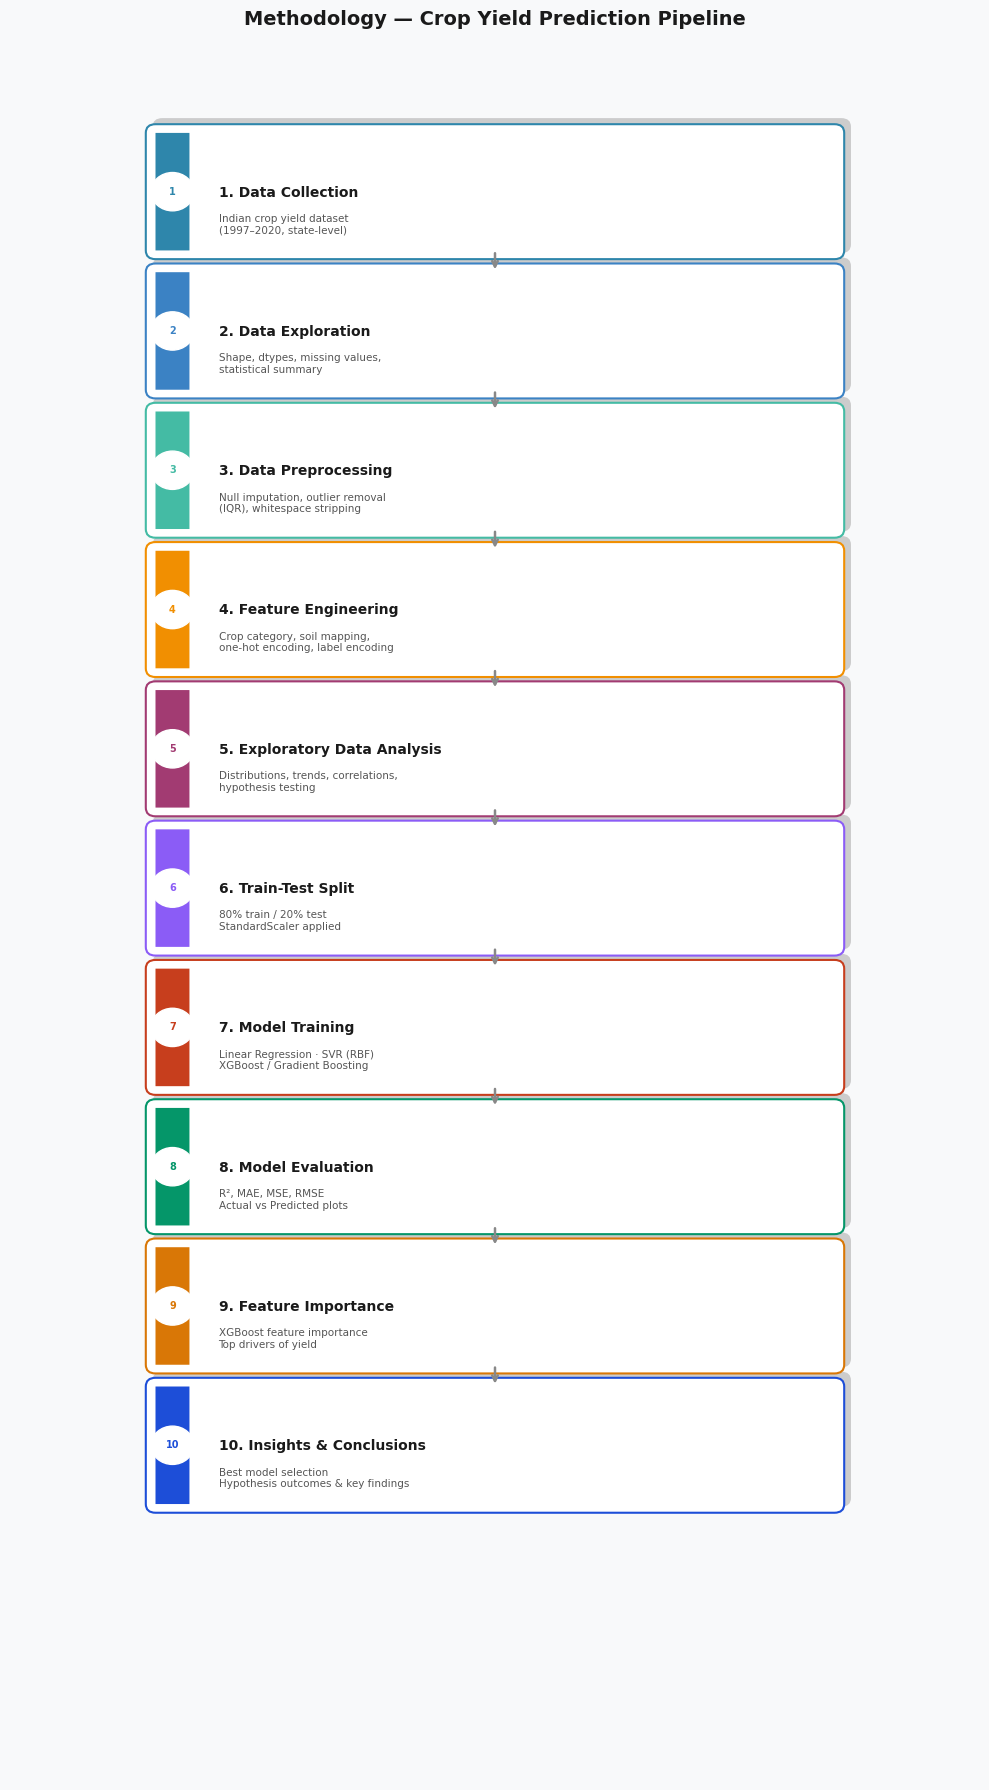

Block diagram saved as methodology_block_diagram.png


In [1]:
# ── Methodology Block Diagram ──────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(10, 18))
ax.set_xlim(0, 10)
ax.set_ylim(0, 20)
ax.axis('off')
fig.patch.set_facecolor('#F8F9FA')

steps = [
    ("1. Data Collection",          "Indian crop yield dataset\n(1997–2020, state-level)",         "#2E86AB"),
    ("2. Data Exploration",         "Shape, dtypes, missing values,\nstatistical summary",          "#3B82C4"),
    ("3. Data Preprocessing",       "Null imputation, outlier removal\n(IQR), whitespace stripping", "#44BBA4"),
    ("4. Feature Engineering",      "Crop category, soil mapping,\none-hot encoding, label encoding","#F18F01"),
    ("5. Exploratory Data Analysis","Distributions, trends, correlations,\nhypothesis testing",     "#A23B72"),
    ("6. Train-Test Split",         "80% train / 20% test\nStandardScaler applied",                 "#8B5CF6"),
    ("7. Model Training",           "Linear Regression · SVR (RBF)\nXGBoost / Gradient Boosting",   "#C73E1D"),
    ("8. Model Evaluation",         "R², MAE, MSE, RMSE\nActual vs Predicted plots",               "#059669"),
    ("9. Feature Importance",       "XGBoost feature importance\nTop drivers of yield",             "#D97706"),
    ("10. Insights & Conclusions",  "Best model selection\nHypothesis outcomes & key findings",     "#1D4ED8"),
]

box_w, box_h = 7, 1.35
x_center = 5
y_start = 19.0
gap = 0.25

for i, (title, desc, color) in enumerate(steps):
    y = y_start - i * (box_h + gap)

    # Shadow
    shadow = FancyBboxPatch((x_center - box_w/2 + 0.07, y - box_h + 0.07 - 0.08),
                             box_w, box_h,
                             boxstyle="round,pad=0.1",
                             linewidth=0, facecolor='#CCCCCC', zorder=1)
    ax.add_patch(shadow)

    # Main box
    box = FancyBboxPatch((x_center - box_w/2, y - box_h - 0.08),
                          box_w, box_h,
                          boxstyle="round,pad=0.1",
                          linewidth=1.5, edgecolor=color,
                          facecolor='white', zorder=2)
    ax.add_patch(box)

    # Colour strip on left
    strip = FancyBboxPatch((x_center - box_w/2, y - box_h - 0.08),
                            0.35, box_h,
                            boxstyle="round,pad=0.0",
                            linewidth=0, facecolor=color, zorder=3)
    ax.add_patch(strip)

    # Step number circle
    circle = plt.Circle((x_center - box_w/2 + 0.175, y - box_h/2 - 0.08), 0.22,
                          color='white', zorder=4)
    ax.add_patch(circle)
    ax.text(x_center - box_w/2 + 0.175, y - box_h/2 - 0.08,
            str(i+1), ha='center', va='center',
            fontsize=7, fontweight='bold', color=color, zorder=5)

    # Title
    ax.text(x_center - box_w/2 + 0.65, y - box_h/2 - 0.01 - 0.08,
            title, ha='left', va='center',
            fontsize=10, fontweight='bold', color='#1a1a1a', zorder=4)

    # Description
    ax.text(x_center - box_w/2 + 0.65, y - box_h/2 - 0.38 - 0.08,
            desc, ha='left', va='center',
            fontsize=7.5, color='#555555', zorder=4)

    # Arrow to next step
    if i < len(steps) - 1:
        arrow_y_start = y - box_h - 0.08
        arrow_y_end   = arrow_y_start - gap
        ax.annotate('', xy=(x_center, arrow_y_end),
                    xytext=(x_center, arrow_y_start),
                    arrowprops=dict(arrowstyle='->', color='#888888',
                                   lw=1.8), zorder=5)

ax.set_title('Methodology — Crop Yield Prediction Pipeline',
             fontsize=14, fontweight='bold', pad=10, color='#1a1a1a')
plt.tight_layout()
plt.savefig('methodology_block_diagram.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("Block diagram saved as methodology_block_diagram.png")


## 0. Imports & Configuration

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor  # XGBoost-equivalent
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance
from scipy import stats

# Styling
plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
PALETTE = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B', '#44BBA4']
print('All imports successful')

All imports successful


---
## 1. Problem Statement & Research Hypotheses

Indian agricultural productivity is highly affected by **climate variability**, **input usage**, and **regional diversity**, leading to persistent crop yield uncertainty.  
This notebook uses **1997–2020 state-level data** to analyze key determinants and develops a machine learning-based predictive framework.

| Hypothesis | Null (H₀) | Alternate (H₁) |
|---|---|---|
| H1 – Climate Impact | Rainfall has no significant impact on crop yield | Rainfall significantly affects crop yield |
| H2 – Agricultural Inputs | Fertilizer & pesticide usage do not affect yield | Fertilizer & pesticide usage significantly improve yield |
| H3 – Crop Type & Volatility | Cash crops & food crops show no yield volatility difference | States with more cash crops exhibit greater yield volatility (high-risk, high-reward) |

---
## 2. Dataset Loading & Exploration

---
## 2a. Soil Type Mapping by State


In [17]:
# Load dataset — update path if needed
df = pd.read_csv('crop_yield.csv')

print(f" Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f" Year Range   : {df['Crop_Year'].min()} – {df['Crop_Year'].max()}")
print(f" Unique Crops : {df['Crop'].nunique()}")
print(f"  Unique States: {df['State'].nunique()}")
print(f"  Seasons      : {[s.strip() for s in df['Season'].unique()]}")
df.head()

 Dataset Shape: 19,689 rows × 10 columns
 Year Range   : 1997 – 2020
 Unique Crops : 55
  Unique States: 30
  Seasons      : ['Whole Year', 'Kharif', 'Rabi', 'Autumn', 'Summer', 'Winter']


,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909


In [18]:
df.tail()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
19684,Small millets,1998,Kharif,Nagaland,4000.0,2000,1498.0,395200.00,1160.00,0.500000
19685,Wheat,1998,Rabi,Nagaland,1000.0,3000,1498.0,98800.00,290.00,3.000000
19686,Maize,1997,Kharif,Jammu and Kashmir,310883.0,440900,1356.2,29586735.11,96373.73,1.285000
19687,Rice,1997,Kharif,Jammu and Kashmir,275746.0,5488,1356.2,26242746.82,85481.26,0.016667
19688,Wheat,1997,Rabi,Jammu and Kashmir,239344.0,392160,1356.2,22778368.48,74196.64,1.261818


### Dataset Visual Summary

In [ ]:
# ── Dataset Visual Summary ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dataset Overview', fontsize=14, fontweight='bold')

# --- Panel 1: Column info table ---
col_info = pd.DataFrame({
    'Column': df.columns,
    'Dtype':  df.dtypes.astype(str).values,
    'Non-Null': df.notnull().sum().values,
    'Missing':  df.isnull().sum().values,
})
axes[0].axis('off')
tbl = axes[0].table(
    cellText=col_info.values,
    colLabels=col_info.columns,
    cellLoc='center', loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.5)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2E86AB')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#EAF4FB')
axes[0].set_title(f'Column Info  ({df.shape[0]:,} rows × {df.shape[1]} cols)',
                  fontweight='bold', pad=10)

# --- Panel 2: Numeric summary table ---
desc = df.describe().T[['mean', 'std', 'min', '50%', 'max']]
desc.columns = ['Mean', 'Std', 'Min', 'Median', 'Max']
desc_rounded = desc.round(2)
axes[1].axis('off')
tbl2 = axes[1].table(
    cellText=desc_rounded.values,
    rowLabels=desc_rounded.index,
    colLabels=desc_rounded.columns,
    cellLoc='center', loc='center'
)
tbl2.auto_set_font_size(False)
tbl2.set_fontsize(8.5)
tbl2.scale(1.1, 1.5)
for (r, c), cell in tbl2.get_celld().items():
    if r == 0:
        cell.set_facecolor('#A23B72')
        cell.set_text_props(color='white', fontweight='bold')
    elif c == -1:
        cell.set_facecolor('#F3E8F0')
        cell.set_text_props(fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#FCF5FA')
axes[1].set_title('Statistical Summary', fontweight='bold')

plt.tight_layout()
plt.savefig('dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dataset overview saved as dataset_overview.png")


In [19]:
print("\n Data Types:")
print(df.dtypes)
print("\n Missing Values:")
print(df.isnull().sum())
print("\n Statistical Summary:")
df.describe()


 Data Types:
Crop                object
Crop_Year            int64
Season              object
State               object
Area               float64
Production           int64
Annual_Rainfall    float64
Fertilizer         float64
Pesticide          float64
Yield              float64
dtype: object

 Missing Values:
Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
dtype: int64

 Statistical Summary:


,Crop_Year,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
count,19689.000000,1.968900e+04,1.968900e+04,19689.000000,1.968900e+04,1.968900e+04,19689.000000
mean,2009.127584,1.799266e+05,1.643594e+07,1437.755177,2.410331e+07,4.884835e+04,79.954009
std,6.498099,7.328287e+05,2.630568e+08,816.909589,9.494600e+07,2.132874e+05,878.306193
min,1997.000000,5.000000e-01,0.000000e+00,301.300000,5.417000e+01,9.000000e-02,0.000000
25%,2004.000000,1.390000e+03,1.393000e+03,940.700000,1.880146e+05,3.567000e+02,0.600000
50%,2010.000000,9.317000e+03,1.380400e+04,1247.600000,1.234957e+06,2.421900e+03,1.030000
75%,2015.000000,7.511200e+04,1.227180e+05,1643.700000,1.000385e+07,2.004170e+04,2.388889
max,2020.000000,5.080810e+07,6.326000e+09,6552.700000,4.835407e+09,1.575051e+07,21105.000000


---
## 3. Data Preprocessing

In [20]:
df_clean = df.copy()

# Strip whitespace from string columns
for col in ['Crop', 'Season', 'State']:
    df_clean[col] = df_clean[col].str.strip()

# Handle missing values (if any)
num_cols = ['Area', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield']
for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Remove extreme outliers using IQR for Yield
Q1 = df_clean['Yield'].quantile(0.01)
Q3 = df_clean['Yield'].quantile(0.99)
df_clean = df_clean[(df_clean['Yield'] >= Q1) & (df_clean['Yield'] <= Q3)]

# Categorize crops → Food vs Commercial
commercial_crops = [
    'Sugarcane', 'Cotton(lint)', 'Jute', 'Tobacco', 'Rubber', 'Coffee',
    'Tea', 'Sunflower', 'Groundnut', 'Soyabean', 'Castor seed', 'Linseed',
    'Sesamum', 'Rapeseed&Mustard', 'Arecanut', 'Coconut'
]
df_clean['Crop_Category'] = df_clean['Crop'].apply(
    lambda x: 'Commercial' if x in commercial_crops else 'Food'
)

# One-Hot Encoding for Season and Crop_Category
df_encoded = pd.get_dummies(df_clean, columns=['Season', 'Crop_Category'], drop_first=True)

# Label encode State and Crop
le_state = LabelEncoder()
le_crop  = LabelEncoder()
df_encoded['State_enc'] = le_state.fit_transform(df_encoded['State'])
df_encoded['Crop_enc']  = le_crop.fit_transform(df_encoded['Crop'])

print(f" After preprocessing: {df_clean.shape[0]:,} records")
print(f"   Food crops     : {(df_clean['Crop_Category']=='Food').sum():,}")
print(f"   Commercial crops: {(df_clean['Crop_Category']=='Commercial').sum():,}")
df_clean[['Crop','Crop_Category']].drop_duplicates().sort_values('Crop_Category').head(20)
# ── Season Consolidation → 4 canonical seasons ──
season_map = {
    'Kharif':      'Summer',
    'Rabi':        'Winter',
    'Zaid':        'Summer',
    'Autumn':      'Autumn',
    'Summer':      'Summer',
    'Winter':      'Winter',
    'Whole Year':  'Whole Year',
    'Whole year':  'Whole Year',
}
df_clean['Season'] = df_clean['Season'].map(season_map).fillna('Whole Year')
print('\n Season values after consolidation:', sorted(df_clean['Season'].unique()))


 After preprocessing: 19,295 records
   Food crops     : 14,759
   Commercial crops: 4,536

 Season values after consolidation: ['Autumn', 'Summer', 'Whole Year', 'Winter']


### Preprocessing Output Visualisation

In [ ]:
# ── Preprocessing Output Visualisation ─────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Preprocessing Output Summary', fontsize=14, fontweight='bold')

# --- 1. Records before vs after outlier removal ---
before = df.shape[0]
after  = df_clean.shape[0]
axes[0,0].bar(['Before\nPreprocessing', 'After\nPreprocessing'],
               [before, after],
               color=[PALETTE[3], PALETTE[0]], edgecolor='white', width=0.5)
for i, v in enumerate([before, after]):
    axes[0,0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold', fontsize=11)
axes[0,0].set_title('Records Before vs After\nOutlier Removal', fontweight='bold')
axes[0,0].set_ylabel('Number of Records')

# --- 2. Yield distribution: before vs after IQR filter ---
axes[0,1].hist(df['Yield'],       bins=60, alpha=0.6, color=PALETTE[3],
               label=f'Before (n={before:,})', edgecolor='white')
axes[0,1].hist(df_clean['Yield'], bins=60, alpha=0.6, color=PALETTE[0],
               label=f'After  (n={after:,})',  edgecolor='white')
axes[0,1].set_title('Yield Distribution\nBefore vs After IQR Filter', fontweight='bold')
axes[0,1].set_xlabel('Yield (tonnes/ha)')
axes[0,1].set_ylabel('Count')
axes[0,1].legend()

# --- 3. Crop Category split (Food vs Commercial) ---
cat_counts = df_clean['Crop_Category'].value_counts()
colors_pie = [PALETTE[0], PALETTE[1]]
wedges, texts, autotexts = axes[0,2].pie(
    cat_counts.values, labels=cat_counts.index,
    autopct='%1.1f%%', colors=colors_pie,
    startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(11); at.set_fontweight('bold')
axes[0,2].set_title('Crop Category Split\n(Food vs Commercial)', fontweight='bold')

# --- 4. Missing values: before vs after imputation ---
missing_before = df[['Area','Production','Annual_Rainfall','Fertilizer','Pesticide','Yield']].isnull().sum()
missing_after  = df_clean[['Area','Production','Annual_Rainfall','Fertilizer','Pesticide','Yield']].isnull().sum()
x = np.arange(len(missing_before))
w = 0.35
axes[1,0].bar(x - w/2, missing_before.values, w, label='Before', color=PALETTE[3], alpha=0.85)
axes[1,0].bar(x + w/2, missing_after.values,  w, label='After',  color=PALETTE[0], alpha=0.85)
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(missing_before.index, rotation=30, ha='right', fontsize=9)
axes[1,0].set_title('Missing Values:\nBefore vs After Imputation', fontweight='bold')
axes[1,0].set_ylabel('Missing Count')
axes[1,0].legend()

# --- 5. Season consolidation: before vs after mapping ---
season_before = df['Season'].str.strip().value_counts()
season_after  = df_clean['Season'].value_counts()
axes[1,1].barh(season_before.index, season_before.values,
               color=PALETTE[2], alpha=0.7, label='Before', height=0.4,
               align='edge')
axes[1,1].barh(season_after.index, season_after.values,
               color=PALETTE[0], alpha=0.9, label='After',  height=-0.4,
               align='edge')
axes[1,1].set_title('Season Consolidation\n(Before vs After Mapping)', fontweight='bold')
axes[1,1].set_xlabel('Record Count')
axes[1,1].legend()

# --- 6. Encoded feature count summary ---
feature_summary = {
    'Raw\nFeatures':      df.shape[1],
    'After Label\nEncode': df.shape[1] + 2,
    'After One-Hot\nEncode': df_encoded.shape[1],
    'Final Model\nFeatures': len(feature_cols) if 'feature_cols' in dir() else df_encoded.shape[1],
}
axes[1,2].bar(feature_summary.keys(), feature_summary.values(),
              color=[PALETTE[i] for i in range(len(feature_summary))],
              edgecolor='white', width=0.55)
for i, (k, v) in enumerate(feature_summary.items()):
    axes[1,2].text(i, v + 0.3, str(v), ha='center', fontweight='bold', fontsize=11)
axes[1,2].set_title('Feature Count\nThrough Preprocessing Pipeline', fontweight='bold')
axes[1,2].set_ylabel('Number of Features / Columns')

plt.tight_layout()
plt.savefig('preprocessing_output.png', dpi=150, bbox_inches='tight')
plt.show()
print("Preprocessing output saved as preprocessing_output.png")


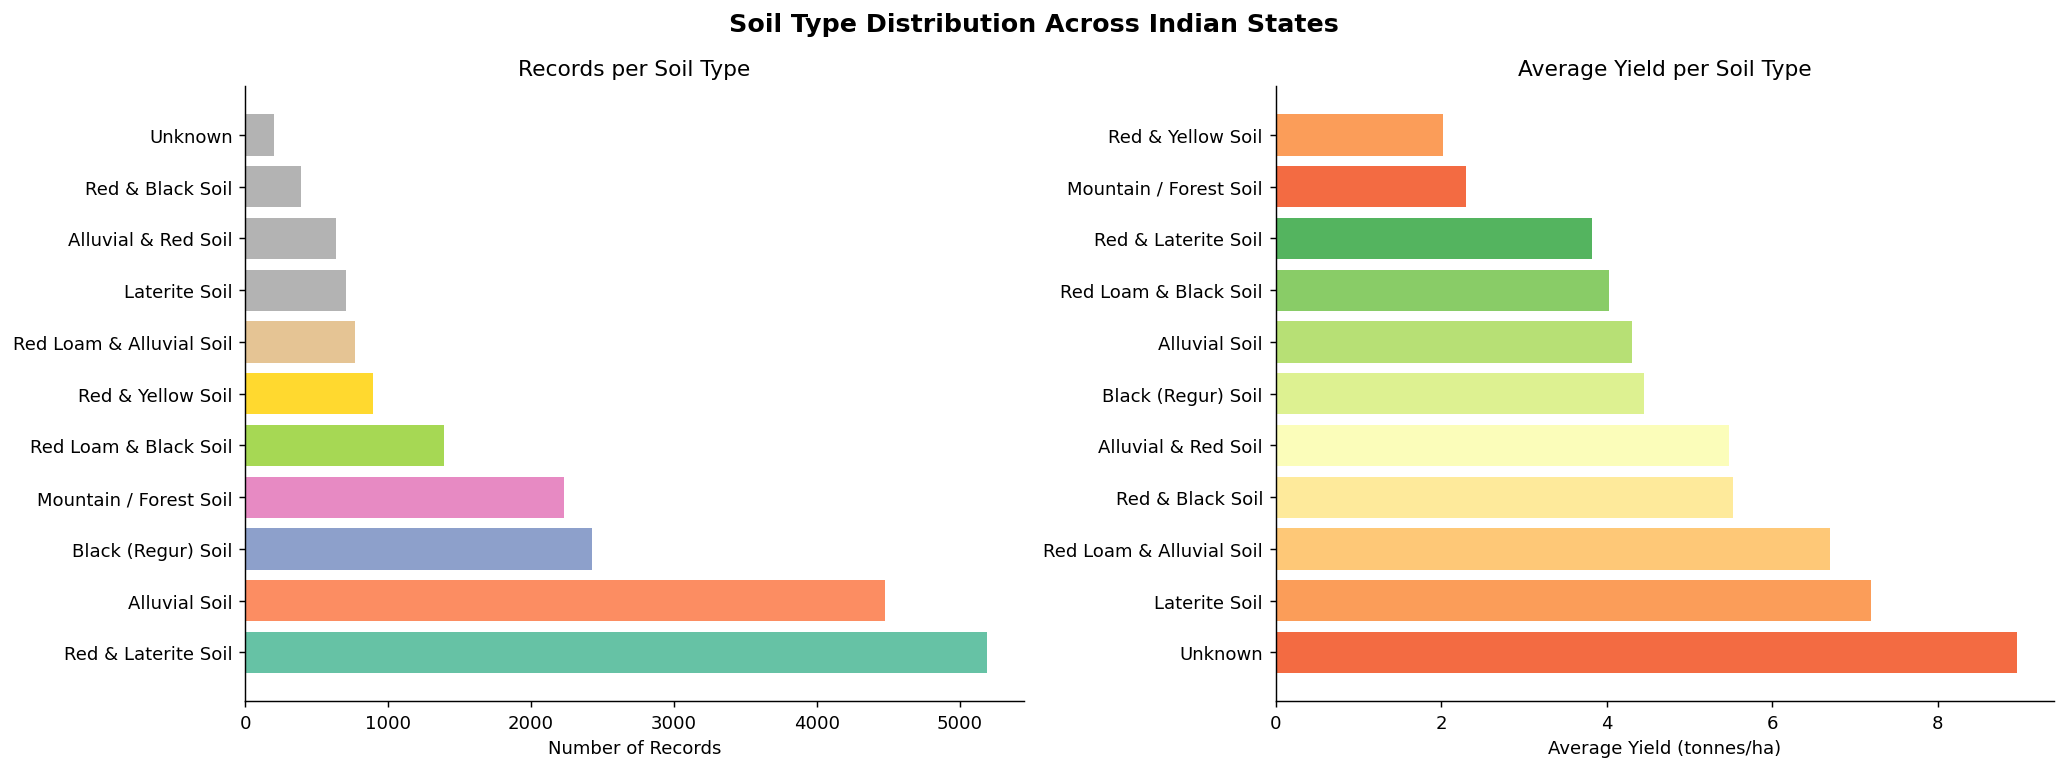


📋 Soil Type per State:
            State                Soil_Type
       Puducherry      Alluvial & Red Soil
            Assam            Alluvial Soil
      West Bengal            Alluvial Soil
          Haryana            Alluvial Soil
    Uttar Pradesh            Alluvial Soil
            Bihar            Alluvial Soil
           Punjab            Alluvial Soil
          Gujarat       Black (Regur) Soil
   Madhya Pradesh       Black (Regur) Soil
      Maharashtra       Black (Regur) Soil
           Kerala            Laterite Soil
              Goa            Laterite Soil
Jammu and Kashmir   Mountain / Forest Soil
      Uttarakhand   Mountain / Forest Soil
 Himachal Pradesh   Mountain / Forest Soil
           Sikkim   Mountain / Forest Soil
        Telangana         Red & Black Soil
           Odisha      Red & Laterite Soil
   Andhra Pradesh      Red & Laterite Soil
          Tripura      Red & Laterite Soil
         Nagaland      Red & Laterite Soil
        Meghalaya      Red & L

In [21]:
# --- State Soil Type Mapping ---
state_soil_map = {
    'Andhra Pradesh':       'Red & Laterite Soil',
    'Arunachal Pradesh':    'Red & Laterite Soil',
    'Assam':                'Alluvial Soil',
    'Bihar':                'Alluvial Soil',
    'Chhattisgarh':         'Red & Yellow Soil',
    'Goa':                  'Laterite Soil',
    'Gujarat':              'Black (Regur) Soil',
    'Haryana':              'Alluvial Soil',
    'Himachal Pradesh':     'Mountain / Forest Soil',
    'Jammu and Kashmir':    'Mountain / Forest Soil',
    'Jharkhand':            'Red & Laterite Soil',
    'Karnataka':            'Red Loam & Black Soil',
    'Kerala':               'Laterite Soil',
    'Madhya Pradesh':       'Black (Regur) Soil',
    'Maharashtra':          'Black (Regur) Soil',
    'Manipur':              'Red & Laterite Soil',
    'Meghalaya':            'Red & Laterite Soil',
    'Mizoram':              'Red & Laterite Soil',
    'Nagaland':             'Red & Laterite Soil',
    'Odisha':               'Red & Laterite Soil',
    'Punjab':               'Alluvial Soil',
    'Rajasthan':            'Sandy / Arid Soil',
    'Sikkim':               'Mountain / Forest Soil',
    'Tamil Nadu':           'Red Loam & Alluvial Soil',
    'Telangana':            'Red & Black Soil',
    'Tripura':              'Red & Laterite Soil',
    'Uttar Pradesh':        'Alluvial Soil',
    'Uttarakhand':          'Mountain / Forest Soil',
    'West Bengal':          'Alluvial Soil',
    'Andaman and Nicobar Islands': 'Red & Laterite Soil',
    'Dadra and Nagar Haveli': 'Laterite Soil',
    'Puducherry':           'Alluvial & Red Soil',
}

df_clean['Soil_Type'] = df_clean['State'].map(state_soil_map).fillna('Unknown')

# Visualise soil type distribution across states
soil_counts = df_clean['Soil_Type'].value_counts().reset_index()
soil_counts.columns = ['Soil_Type', 'Count']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Soil Type Distribution Across Indian States', fontsize=14, fontweight='bold')

# Bar chart of records per soil type
axes[0].barh(soil_counts['Soil_Type'], soil_counts['Count'],
             color=plt.cm.Set2(range(len(soil_counts))))
axes[0].set_title('Records per Soil Type')
axes[0].set_xlabel('Number of Records')

# Average yield per soil type
soil_yield = df_clean.groupby('Soil_Type')['Yield'].mean().sort_values(ascending=False).reset_index()
colors_bar = plt.cm.RdYlGn(range(50, 230, 230//len(soil_yield)))
axes[1].barh(soil_yield['Soil_Type'], soil_yield['Yield'], color=colors_bar)
axes[1].set_title('Average Yield per Soil Type')
axes[1].set_xlabel('Average Yield (tonnes/ha)')

plt.tight_layout()
plt.show()

print('\n Soil Type per State:')
print(df_clean[['State','Soil_Type']].drop_duplicates().sort_values('Soil_Type').to_string(index=False))


---
## 4. Exploratory Data Analysis (EDA)

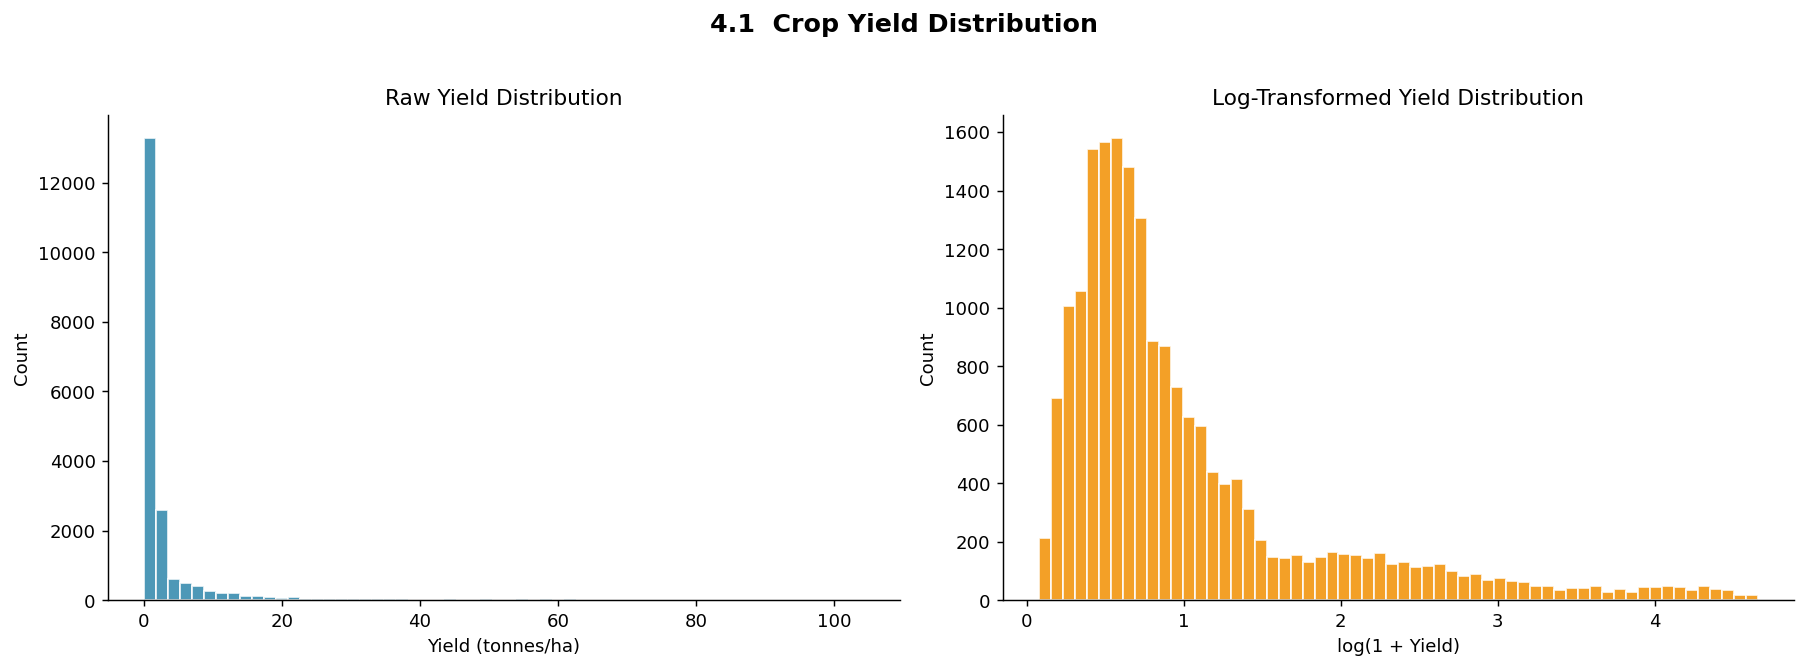

In [22]:
# --- 4.1 Yield Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('4.1  Crop Yield Distribution', fontsize=14, fontweight='bold', y=1.02)

axes[0].hist(df_clean['Yield'], bins=60, color=PALETTE[0], edgecolor='white', alpha=0.85)
axes[0].set_title('Raw Yield Distribution')
axes[0].set_xlabel('Yield (tonnes/ha)')
axes[0].set_ylabel('Count')

log_yield = np.log1p(df_clean['Yield'])
axes[1].hist(log_yield, bins=60, color=PALETTE[2], edgecolor='white', alpha=0.85)
axes[1].set_title('Log-Transformed Yield Distribution')
axes[1].set_xlabel('log(1 + Yield)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

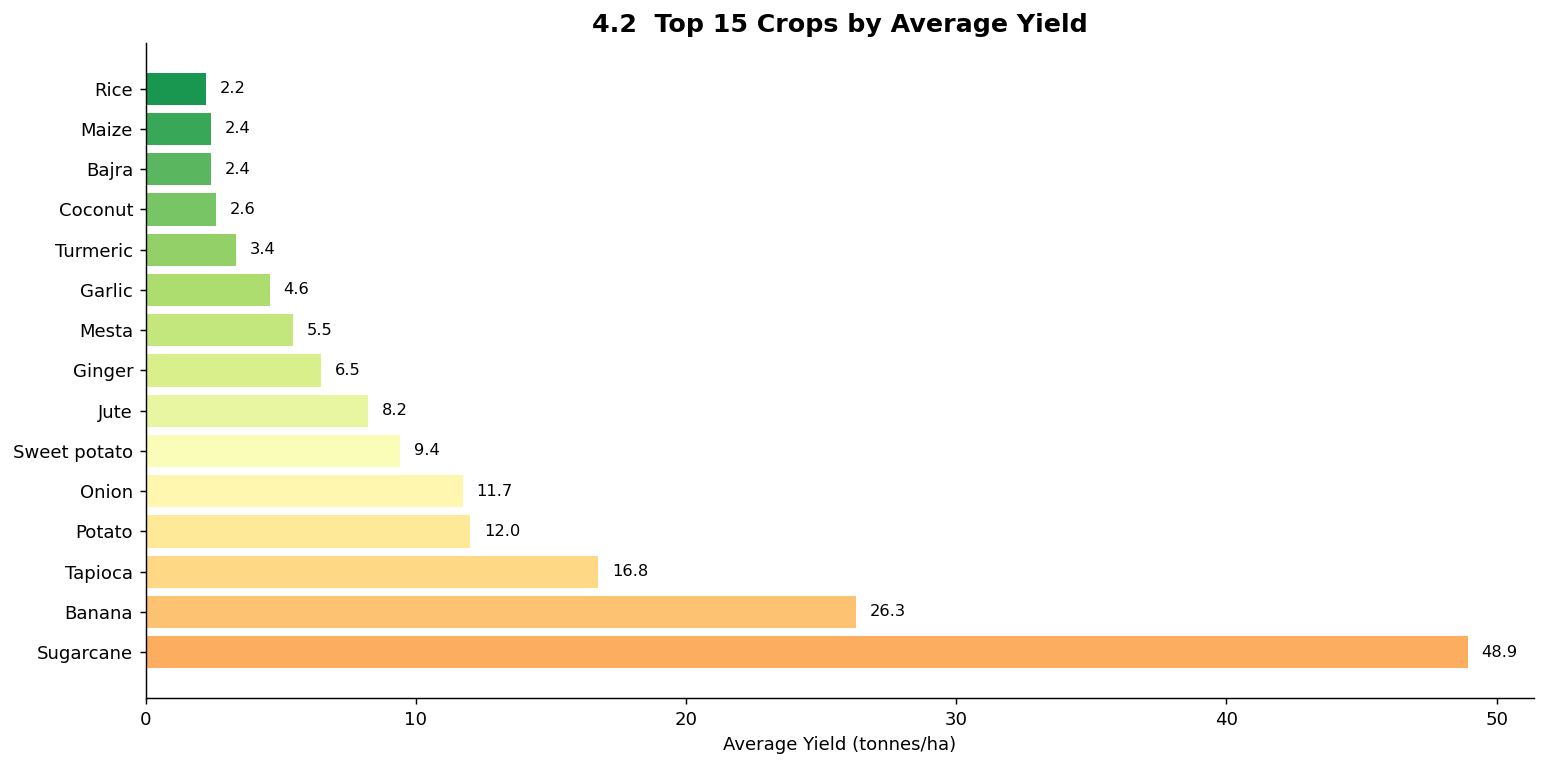

In [23]:
# --- 4.2 Top 15 Crops by Average Yield ---
top_crops = df_clean.groupby('Crop')['Yield'].mean().nlargest(15).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_crops['Crop'], top_crops['Yield'],
               color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, 15)))
ax.set_title('4.2  Top 15 Crops by Average Yield', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Yield (tonnes/ha)')
for bar, val in zip(bars, top_crops['Yield']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

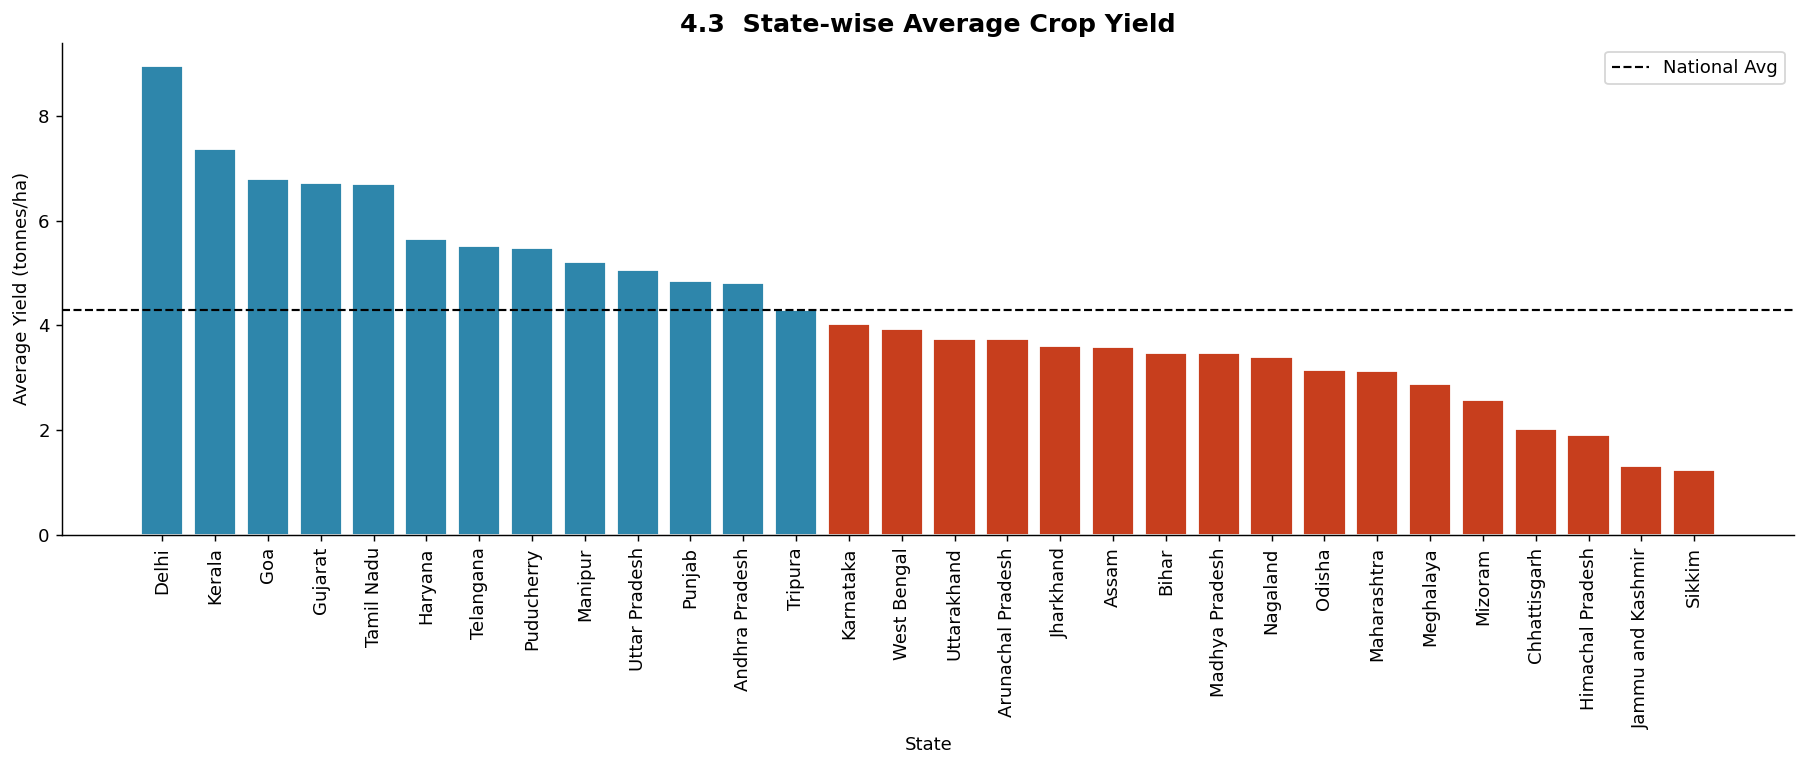

In [24]:
# --- 4.3 State-wise Average Yield ---
state_yield = df_clean.groupby('State')['Yield'].mean().sort_values(ascending=False).reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
colors = [PALETTE[0] if y > state_yield['Yield'].mean() else PALETTE[3] for y in state_yield['Yield']]
ax.bar(state_yield['State'], state_yield['Yield'], color=colors, edgecolor='white')
ax.axhline(state_yield['Yield'].mean(), color='black', linestyle='--', linewidth=1.2, label='National Avg')
ax.set_title('4.3  State-wise Average Crop Yield', fontsize=14, fontweight='bold')
ax.set_xlabel('State')
ax.set_ylabel('Average Yield (tonnes/ha)')
ax.tick_params(axis='x', rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

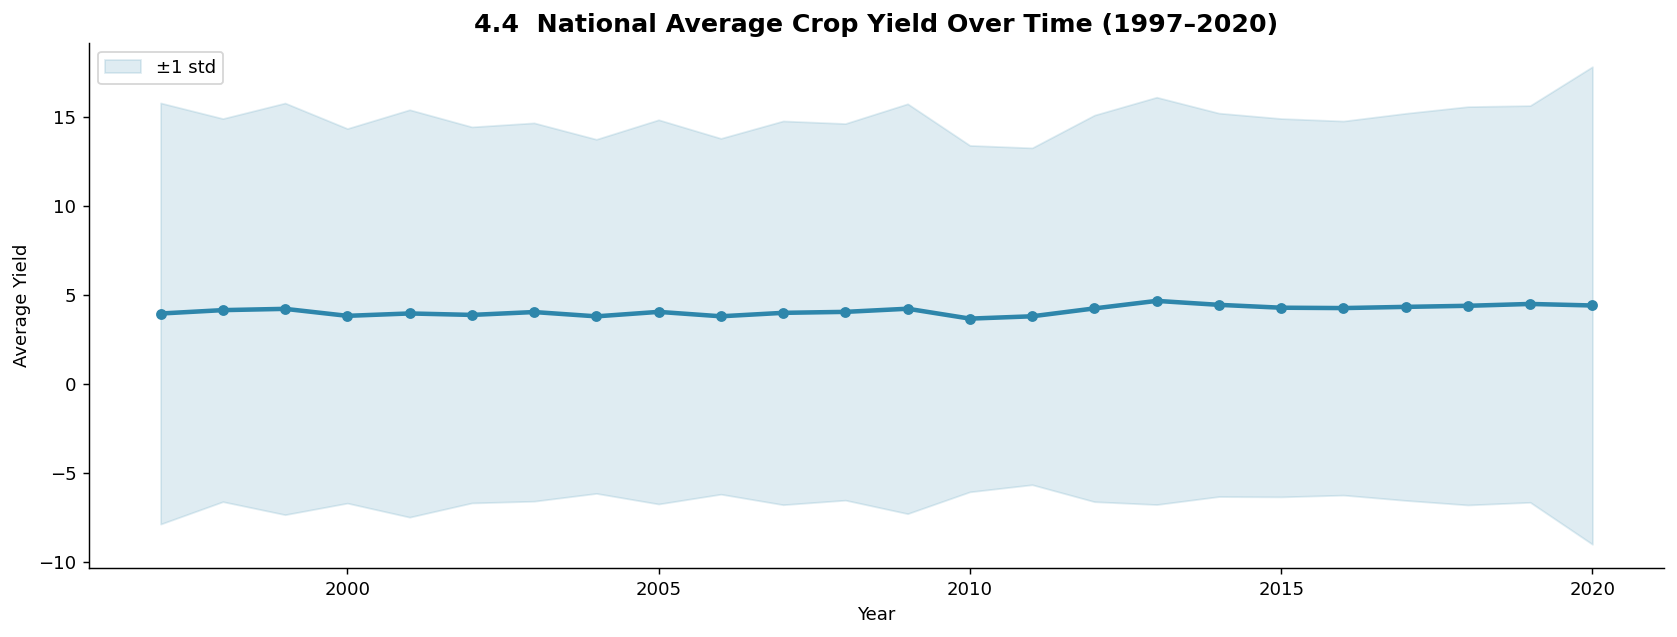

In [25]:
# --- 4.4 Yield Trend Over Years ---
yearly = df_clean.groupby('Crop_Year')['Yield'].agg(['mean','std']).reset_index()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(yearly['Crop_Year'], yearly['mean'], color=PALETTE[0], linewidth=2.5, marker='o', markersize=5)
ax.fill_between(yearly['Crop_Year'],
                yearly['mean'] - yearly['std'],
                yearly['mean'] + yearly['std'],
                alpha=0.15, color=PALETTE[0], label='±1 std')
ax.set_title('4.4  National Average Crop Yield Over Time (1997–2020)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Average Yield')
ax.legend()
plt.tight_layout()
plt.show()

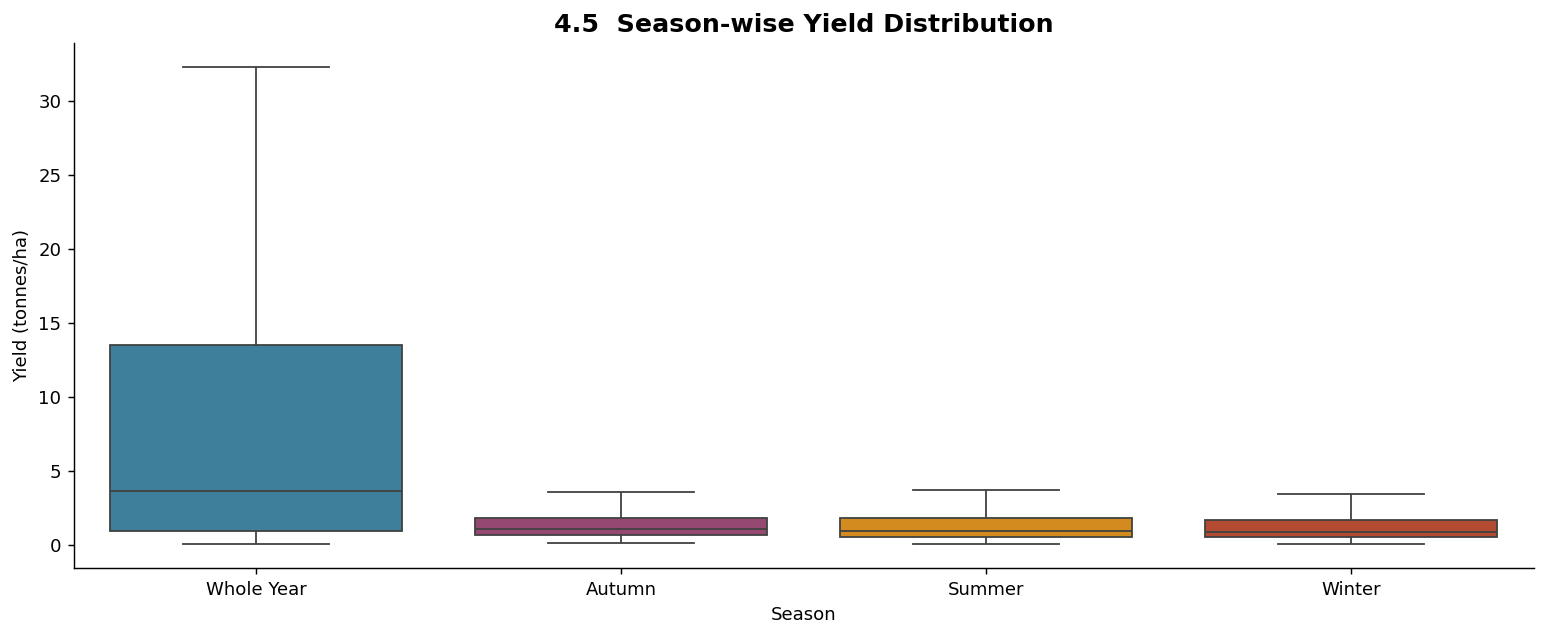

In [26]:
# --- 4.5 Season-wise Yield Distribution ---
fig, ax = plt.subplots(figsize=(12, 5))
season_order = df_clean.groupby('Season')['Yield'].median().sort_values(ascending=False).index
sns.boxplot(data=df_clean, x='Season', y='Yield', order=season_order,
            palette=PALETTE[:6], ax=ax, showfliers=False)
ax.set_title('4.5  Season-wise Yield Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Yield (tonnes/ha)')
plt.tight_layout()
plt.show()

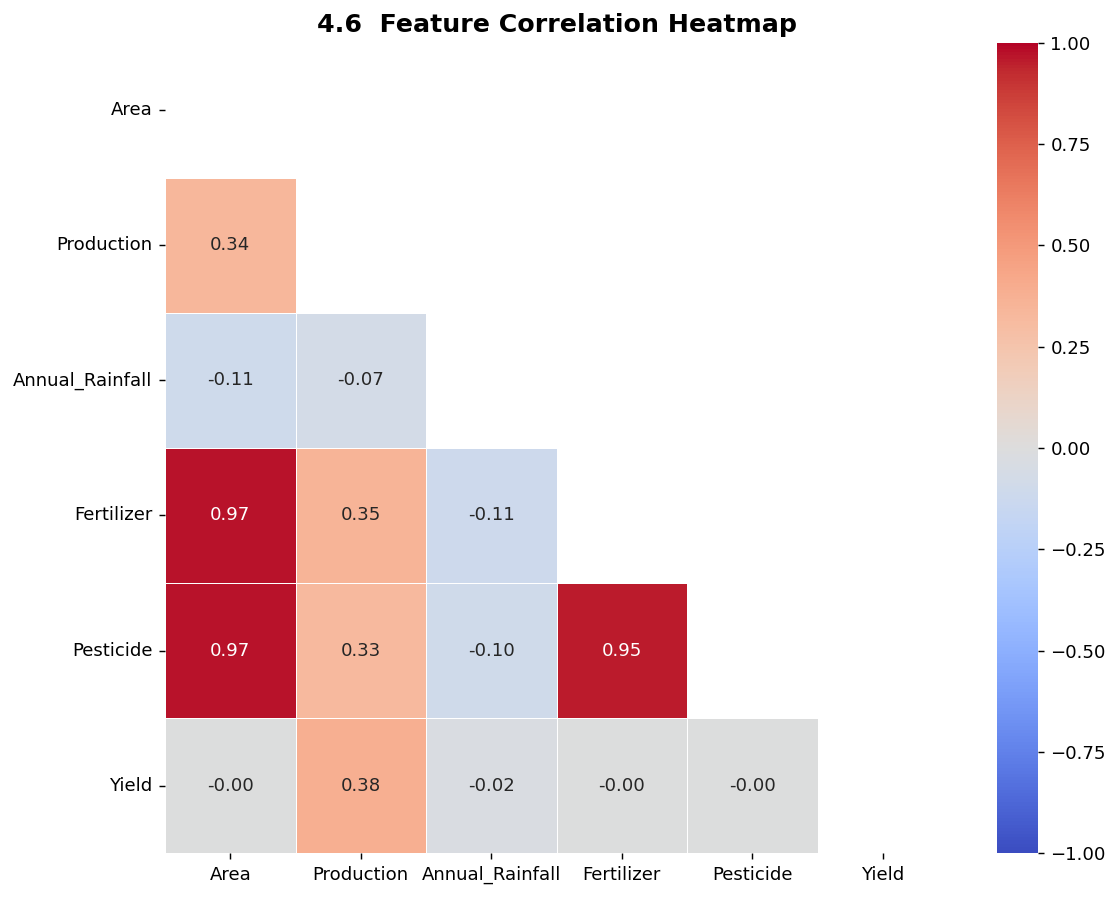

In [27]:
# --- 4.6 Correlation Heatmap ---
fig, ax = plt.subplots(figsize=(9, 7))
corr_cols = ['Area', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield']
corr = df_clean[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', mask=mask,
            linewidths=0.5, ax=ax, center=0, vmin=-1, vmax=1)
ax.set_title('4.6  Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Hypothesis Testing

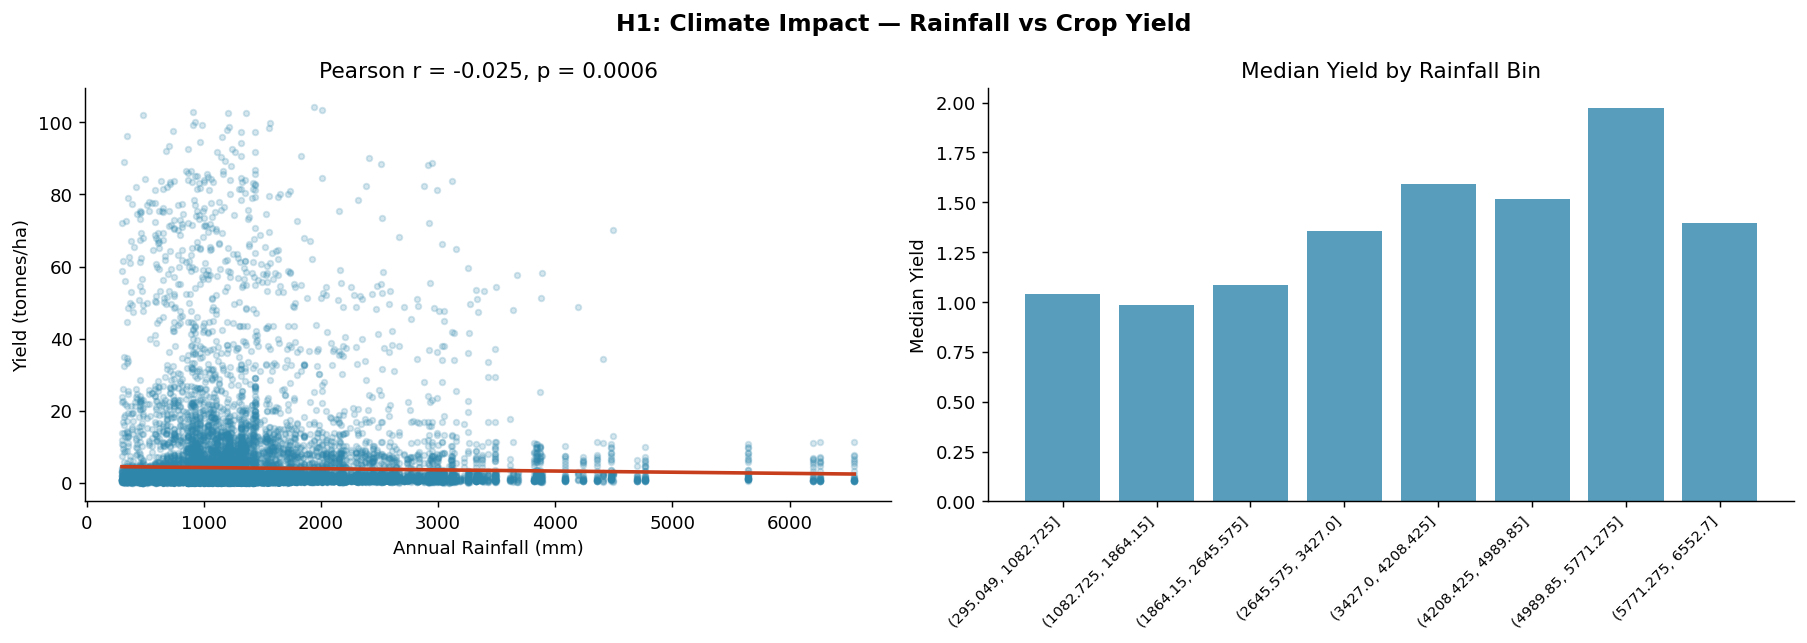


 H1 Result: Pearson r = -0.0246, p-value = 0.000629
    REJECT H₀ — Rainfall significantly affects crop yield.


In [28]:
# ── H1: Rainfall vs Yield ──────────────────────────────────────────────
corr_r, p_val_r = stats.pearsonr(df_clean['Annual_Rainfall'], df_clean['Yield'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('H1: Climate Impact — Rainfall vs Crop Yield', fontsize=13, fontweight='bold')

# Scatter
axes[0].scatter(df_clean['Annual_Rainfall'], df_clean['Yield'],
                alpha=0.2, s=10, color=PALETTE[0])
m, b = np.polyfit(df_clean['Annual_Rainfall'], df_clean['Yield'], 1)
x_line = np.linspace(df_clean['Annual_Rainfall'].min(), df_clean['Annual_Rainfall'].max(), 300)
axes[0].plot(x_line, m*x_line + b, color=PALETTE[3], linewidth=2)
axes[0].set_xlabel('Annual Rainfall (mm)')
axes[0].set_ylabel('Yield (tonnes/ha)')
axes[0].set_title(f'Pearson r = {corr_r:.3f}, p = {p_val_r:.4f}')

# Rainfall bins vs median yield
df_clean['Rainfall_bin'] = pd.cut(df_clean['Annual_Rainfall'], bins=8)
rain_yield = df_clean.groupby('Rainfall_bin')['Yield'].median().reset_index()
axes[1].bar(range(len(rain_yield)), rain_yield['Yield'], color=PALETTE[0], alpha=0.8)
axes[1].set_xticks(range(len(rain_yield)))
axes[1].set_xticklabels([str(b) for b in rain_yield['Rainfall_bin']], rotation=45, ha='right', fontsize=8)
axes[1].set_title('Median Yield by Rainfall Bin')
axes[1].set_ylabel('Median Yield')

plt.tight_layout()
plt.show()

alpha = 0.05
print(f"\n H1 Result: Pearson r = {corr_r:.4f}, p-value = {p_val_r:.6f}")
print(f"   {' REJECT H₀ — Rainfall significantly affects crop yield.' if p_val_r < alpha else '❌ FAIL TO REJECT H₀'}")

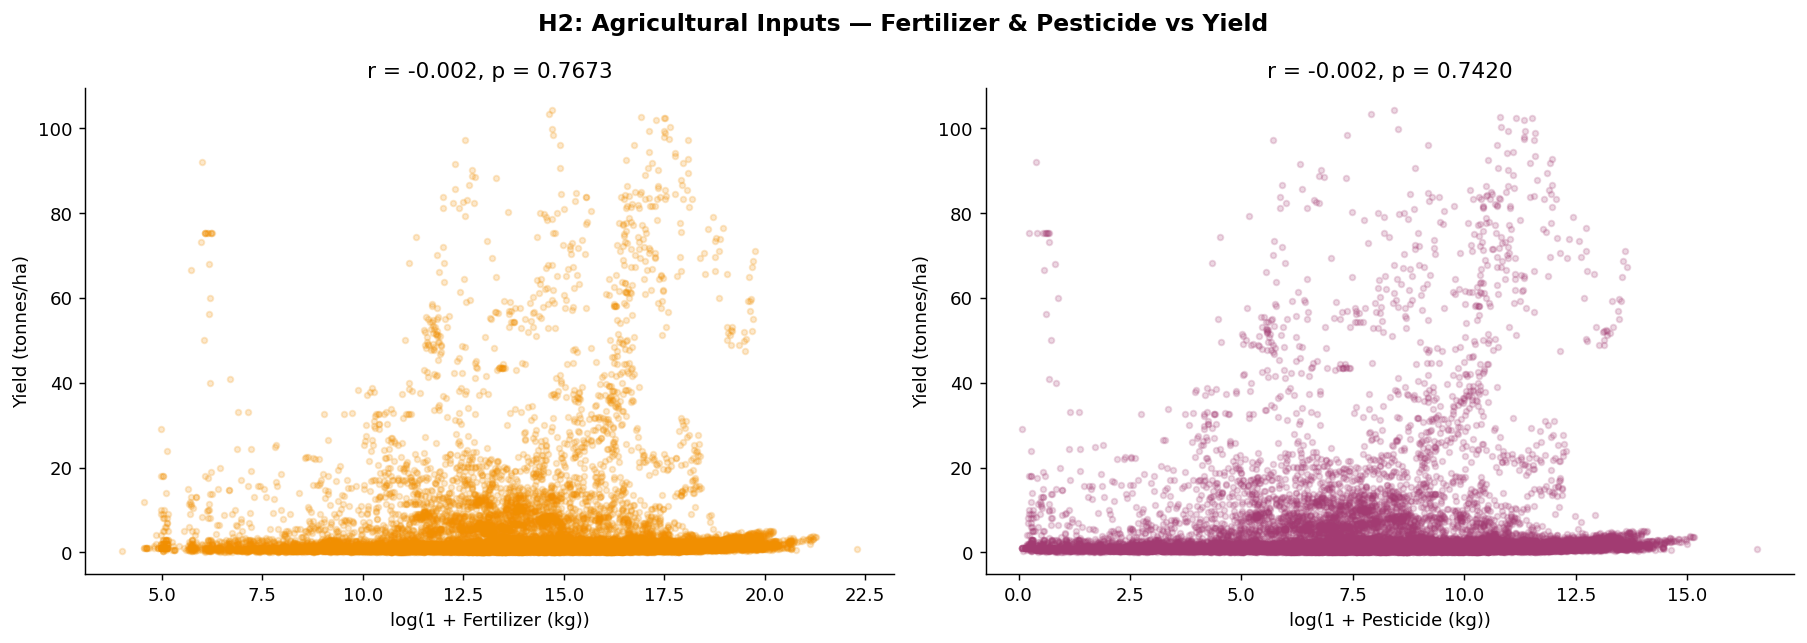


 H2 Result:
   Fertilizer: r = -0.0021, p = 0.767342 →  FAIL TO REJECT H₀
   Pesticide : r = -0.0024, p = 0.742024 →  FAIL TO REJECT H₀


In [29]:
# ── H2: Agricultural Inputs vs Yield ──────────────────────────────────
corr_f, p_val_f = stats.pearsonr(df_clean['Fertilizer'], df_clean['Yield'])
corr_p, p_val_p = stats.pearsonr(df_clean['Pesticide'],  df_clean['Yield'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('H2: Agricultural Inputs — Fertilizer & Pesticide vs Yield', fontsize=13, fontweight='bold')

for ax, col, corr_val, p_val, label, color in [
    (axes[0], 'Fertilizer', corr_f, p_val_f, 'Fertilizer (kg)', PALETTE[2]),
    (axes[1], 'Pesticide',  corr_p, p_val_p, 'Pesticide (kg)',  PALETTE[1]),
]:
    ax.scatter(np.log1p(df_clean[col]), df_clean['Yield'],
               alpha=0.2, s=10, color=color)
    ax.set_xlabel(f'log(1 + {label})')
    ax.set_ylabel('Yield (tonnes/ha)')
    ax.set_title(f'r = {corr_val:.3f}, p = {p_val:.4f}')

plt.tight_layout()
plt.show()

print(f"\n H2 Result:")
print(f"   Fertilizer: r = {corr_f:.4f}, p = {p_val_f:.6f} → {' REJECT H₀' if p_val_f < 0.05 else ' FAIL TO REJECT H₀'}")
print(f"   Pesticide : r = {corr_p:.4f}, p = {p_val_p:.6f} → {' REJECT H₀' if p_val_p < 0.05 else ' FAIL TO REJECT H₀'}")

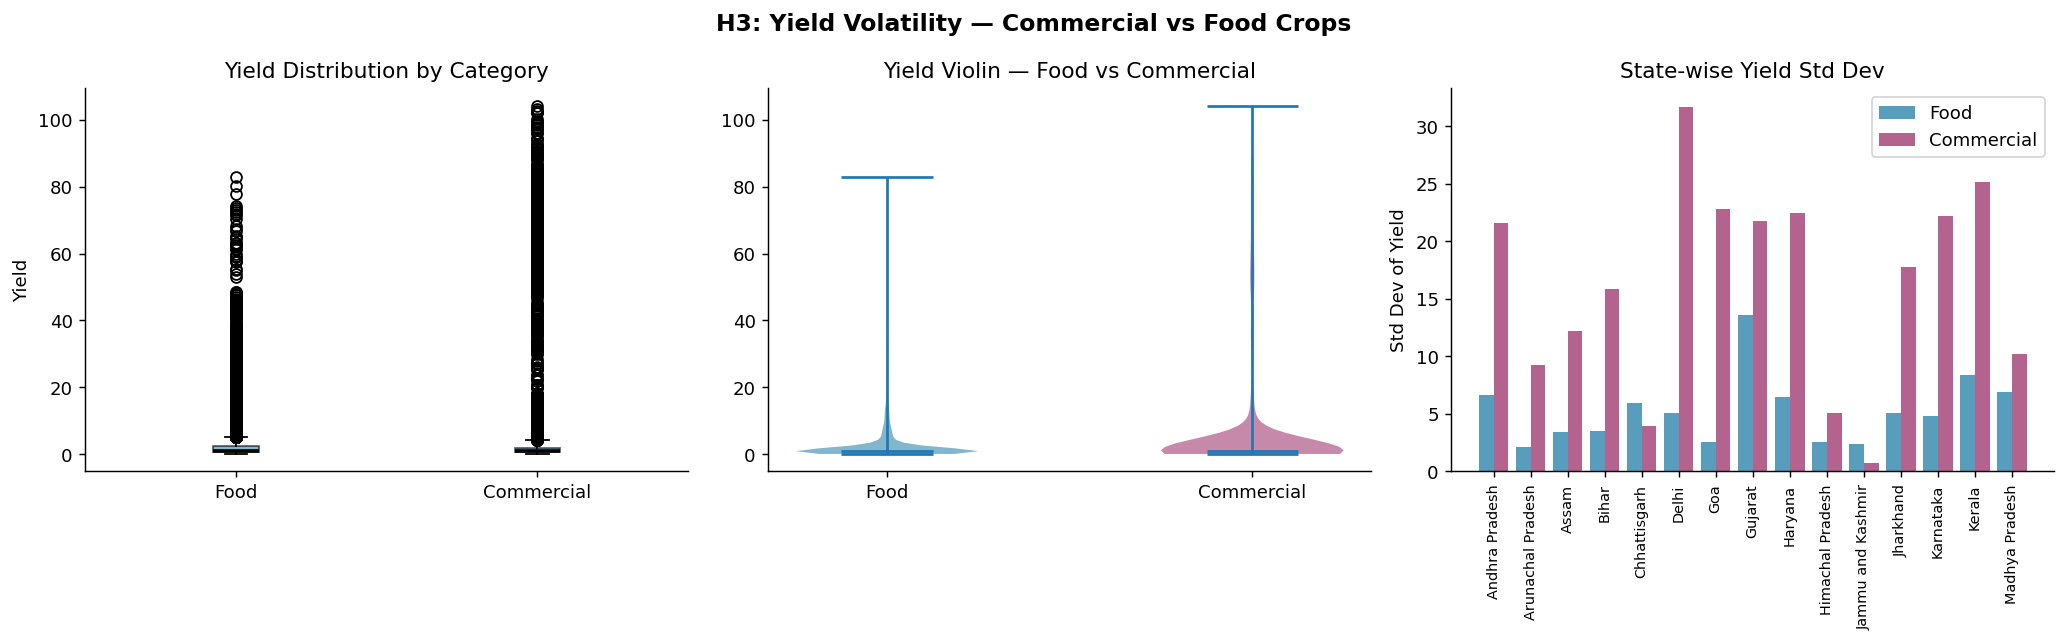


 H3 Result (Levene's test for equal variance):
   Food Crop Std Dev      : 6.0790
   Commercial Crop Std Dev: 18.8791
   Levene stat = 649.3788, p = 0.000000
    REJECT H₀ — Commercial crops show significantly greater yield volatility.


In [30]:
# ── H3: Cash Crop vs Food Crop Yield Volatility ────────────────────────
food_yield       = df_clean[df_clean['Crop_Category'] == 'Food']['Yield']
commercial_yield = df_clean[df_clean['Crop_Category'] == 'Commercial']['Yield']

t_stat, p_val_h3 = stats.levene(food_yield, commercial_yield)  # Levene's test for variance equality

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('H3: Yield Volatility — Commercial vs Food Crops', fontsize=13, fontweight='bold')

# Boxplot
axes[0].boxplot([food_yield, commercial_yield], labels=['Food', 'Commercial'],
                patch_artist=True,
                boxprops=dict(facecolor=PALETTE[0], alpha=0.6),
                medianprops=dict(color='black', linewidth=2))
axes[0].set_title('Yield Distribution by Category')
axes[0].set_ylabel('Yield')

# Violin
parts = axes[1].violinplot([food_yield, commercial_yield], positions=[1, 2],
                            showmedians=True, showextrema=True)
for pc, c in zip(parts['bodies'], [PALETTE[0], PALETTE[1]]):
    pc.set_facecolor(c)
    pc.set_alpha(0.6)
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(['Food', 'Commercial'])
axes[1].set_title('Yield Violin — Food vs Commercial')

# State-wise volatility (std dev) split by category
vol_state = df_clean.groupby(['State', 'Crop_Category'])['Yield'].std().reset_index()
food_vol  = vol_state[vol_state['Crop_Category'] == 'Food'].set_index('State')['Yield']
comm_vol  = vol_state[vol_state['Crop_Category'] == 'Commercial'].set_index('State')['Yield']
common_states = food_vol.index.intersection(comm_vol.index)[:15]
x = np.arange(len(common_states))
axes[2].bar(x - 0.2, food_vol[common_states], 0.4, label='Food',  color=PALETTE[0], alpha=0.8)
axes[2].bar(x + 0.2, comm_vol[common_states], 0.4, label='Commercial', color=PALETTE[1], alpha=0.8)
axes[2].set_xticks(x)
axes[2].set_xticklabels(common_states, rotation=90, fontsize=8)
axes[2].set_title('State-wise Yield Std Dev')
axes[2].set_ylabel('Std Dev of Yield')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"\n H3 Result (Levene's test for equal variance):")
print(f"   Food Crop Std Dev      : {food_yield.std():.4f}")
print(f"   Commercial Crop Std Dev: {commercial_yield.std():.4f}")
print(f"   Levene stat = {t_stat:.4f}, p = {p_val_h3:.6f}")
print(f"   {' REJECT H₀ — Commercial crops show significantly greater yield volatility.' if p_val_h3 < 0.05 else ' FAIL TO REJECT H₀'}")

---
## 6. Feature Engineering & Train-Test Split

In [31]:
# Select features for modelling
feature_cols = [
    'Area', 'Annual_Rainfall', 'Fertilizer', 'Pesticide',
    'Crop_Year', 'State_enc', 'Crop_enc'
]

# Add one-hot encoded season and category columns
ohe_cols = [c for c in df_encoded.columns if c.startswith('Season_') or c.startswith('Crop_Category_')]
feature_cols += ohe_cols

X = df_encoded[feature_cols].values
y = df_encoded['Yield'].values

# 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f" Feature matrix shape : {X.shape}")
print(f"   Train set : {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"   Test  set : {X_test.shape[0]:,}  rows ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"   Features  : {feature_cols}")

 Feature matrix shape : (19295, 13)
   Train set : 15,436 rows (80%)
   Test  set : 3,859  rows (20%)
   Features  : ['Area', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Crop_Year', 'State_enc', 'Crop_enc', 'Season_Kharif', 'Season_Rabi', 'Season_Summer', 'Season_Whole Year', 'Season_Winter', 'Crop_Category_Food']


---
## 7. Model Training & Evaluation
### 7.1 Linear Regression (Baseline — H1: Rainfall)

 LINEAR REGRESSION
   R²   = 0.1976
   MAE  = 4.6492
   MSE  = 87.5678
   RMSE = 9.3578


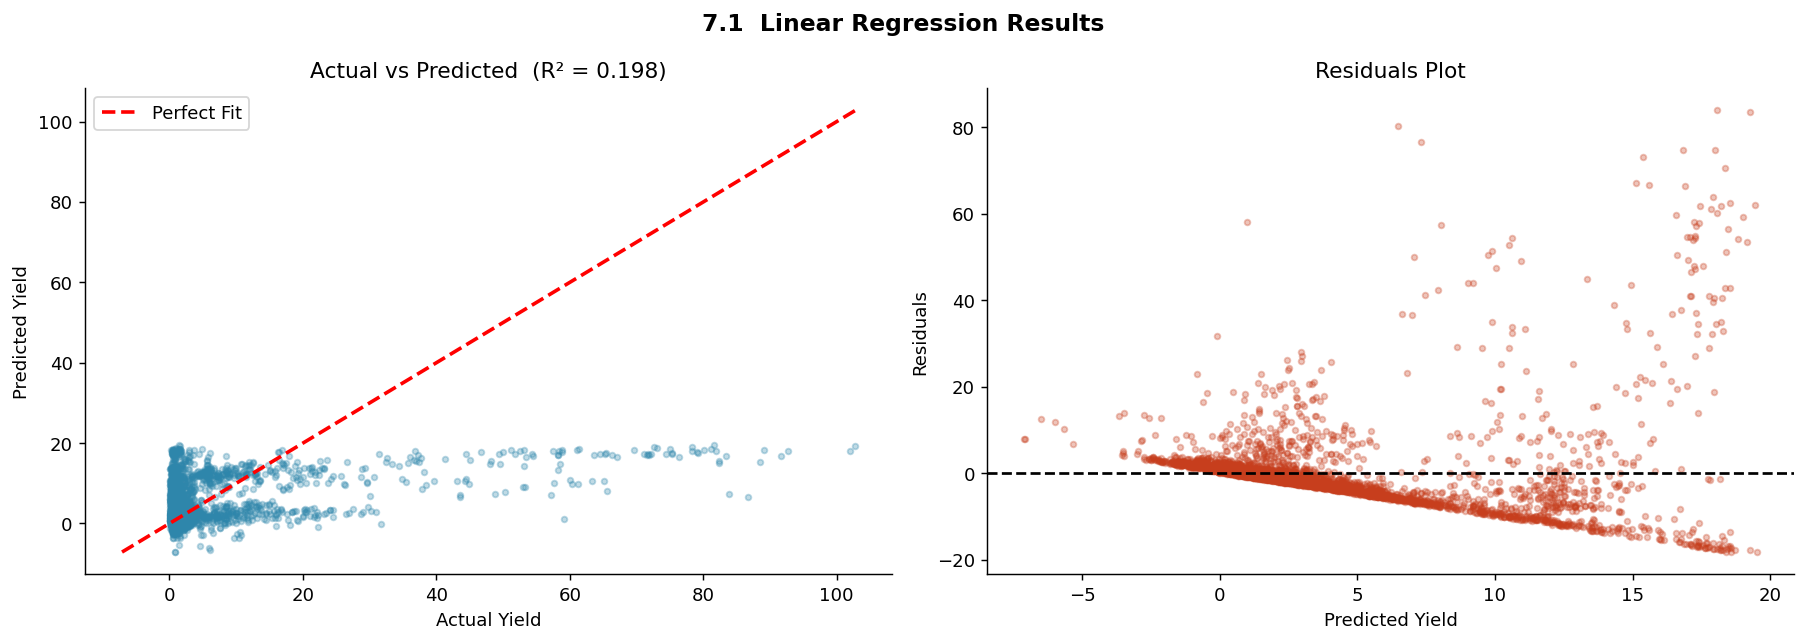

In [32]:
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

r2_lr   = r2_score(y_test, y_pred_lr)
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
mse_lr  = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)

print(" LINEAR REGRESSION")
print(f"   R²   = {r2_lr:.4f}")
print(f"   MAE  = {mae_lr:.4f}")
print(f"   MSE  = {mse_lr:.4f}")
print(f"   RMSE = {rmse_lr:.4f}")

# Predicted vs Actual plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('7.1  Linear Regression Results', fontsize=13, fontweight='bold')

axes[0].scatter(y_test, y_pred_lr, alpha=0.3, s=10, color=PALETTE[0])
lims = [min(y_test.min(), y_pred_lr.min()), max(y_test.max(), y_pred_lr.max())]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Perfect Fit')
axes[0].set_xlabel('Actual Yield')
axes[0].set_ylabel('Predicted Yield')
axes[0].set_title(f'Actual vs Predicted  (R² = {r2_lr:.3f})')
axes[0].legend()

residuals_lr = y_test - y_pred_lr
axes[1].scatter(y_pred_lr, residuals_lr, alpha=0.3, s=10, color=PALETTE[3])
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted Yield')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals Plot')

plt.tight_layout()
plt.show()

### 7.2 Support Vector Regression (Non-linear — H2: Agricultural Inputs)

 SUPPORT VECTOR REGRESSION (RBF Kernel)
   R²   = 0.3252
   MAE  = 2.8582
   MSE  = 73.6436
   RMSE = 8.5816


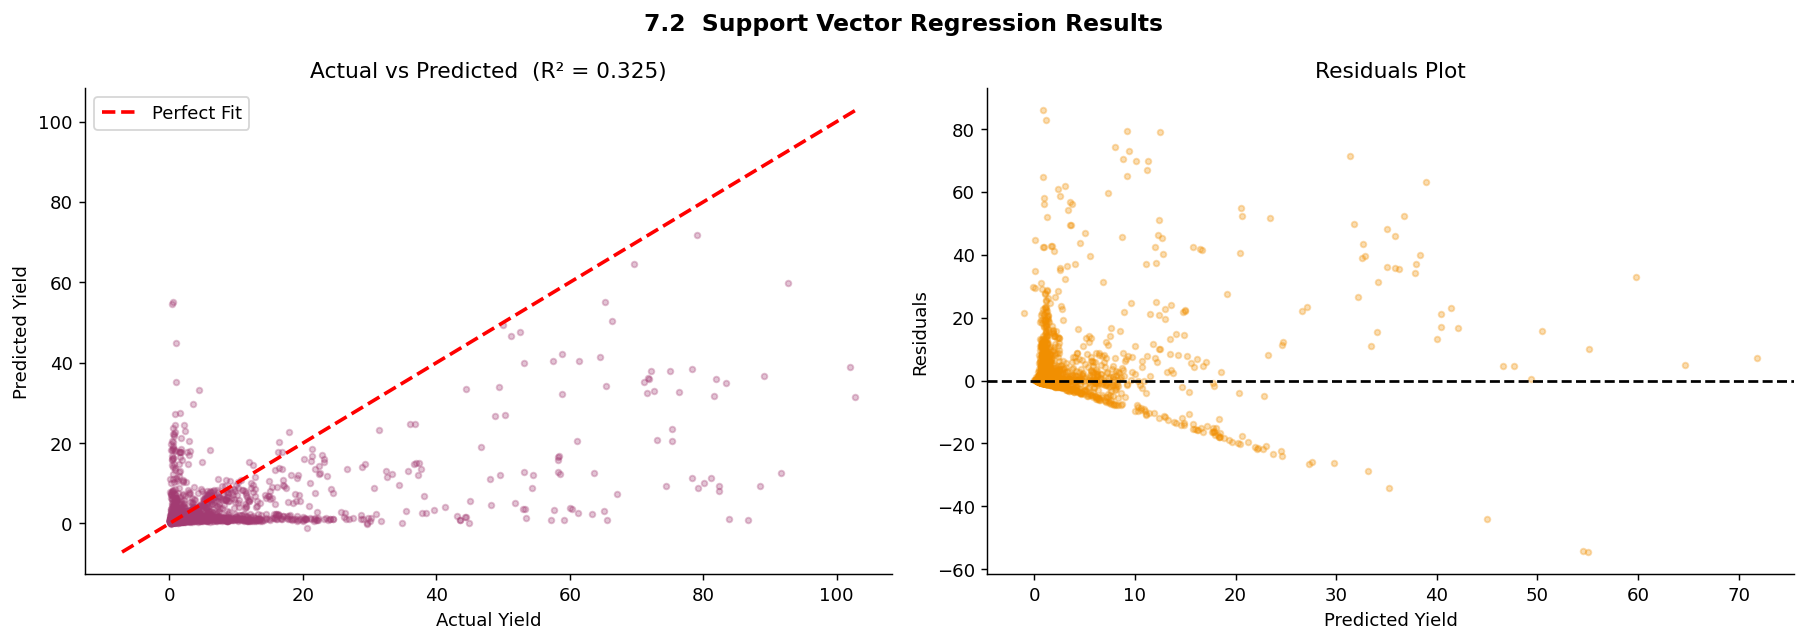

In [33]:
svr = SVR(kernel='rbf', C=10, gamma='scale', epsilon=0.1)
svr.fit(X_train_sc, y_train)
y_pred_svr = svr.predict(X_test_sc)

r2_svr   = r2_score(y_test, y_pred_svr)
mae_svr  = mean_absolute_error(y_test, y_pred_svr)
mse_svr  = mean_squared_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)

print(" SUPPORT VECTOR REGRESSION (RBF Kernel)")
print(f"   R²   = {r2_svr:.4f}")
print(f"   MAE  = {mae_svr:.4f}")
print(f"   MSE  = {mse_svr:.4f}")
print(f"   RMSE = {rmse_svr:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('7.2  Support Vector Regression Results', fontsize=13, fontweight='bold')

axes[0].scatter(y_test, y_pred_svr, alpha=0.3, s=10, color=PALETTE[1])
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Perfect Fit')
axes[0].set_xlabel('Actual Yield'); axes[0].set_ylabel('Predicted Yield')
axes[0].set_title(f'Actual vs Predicted  (R² = {r2_svr:.3f})')
axes[0].legend()

residuals_svr = y_test - y_pred_svr
axes[1].scatter(y_pred_svr, residuals_svr, alpha=0.3, s=10, color=PALETTE[2])
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted Yield'); axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals Plot')

plt.tight_layout()
plt.show()

### 7.3 XGBoost / Gradient Boosting (Ensemble — H3: Crop Type)

 GRADIENT BOOSTING (XGBoost-equivalent)
   R²   = 0.9315
   MAE  = 1.1705
   MSE  = 7.4768
   RMSE = 2.7344


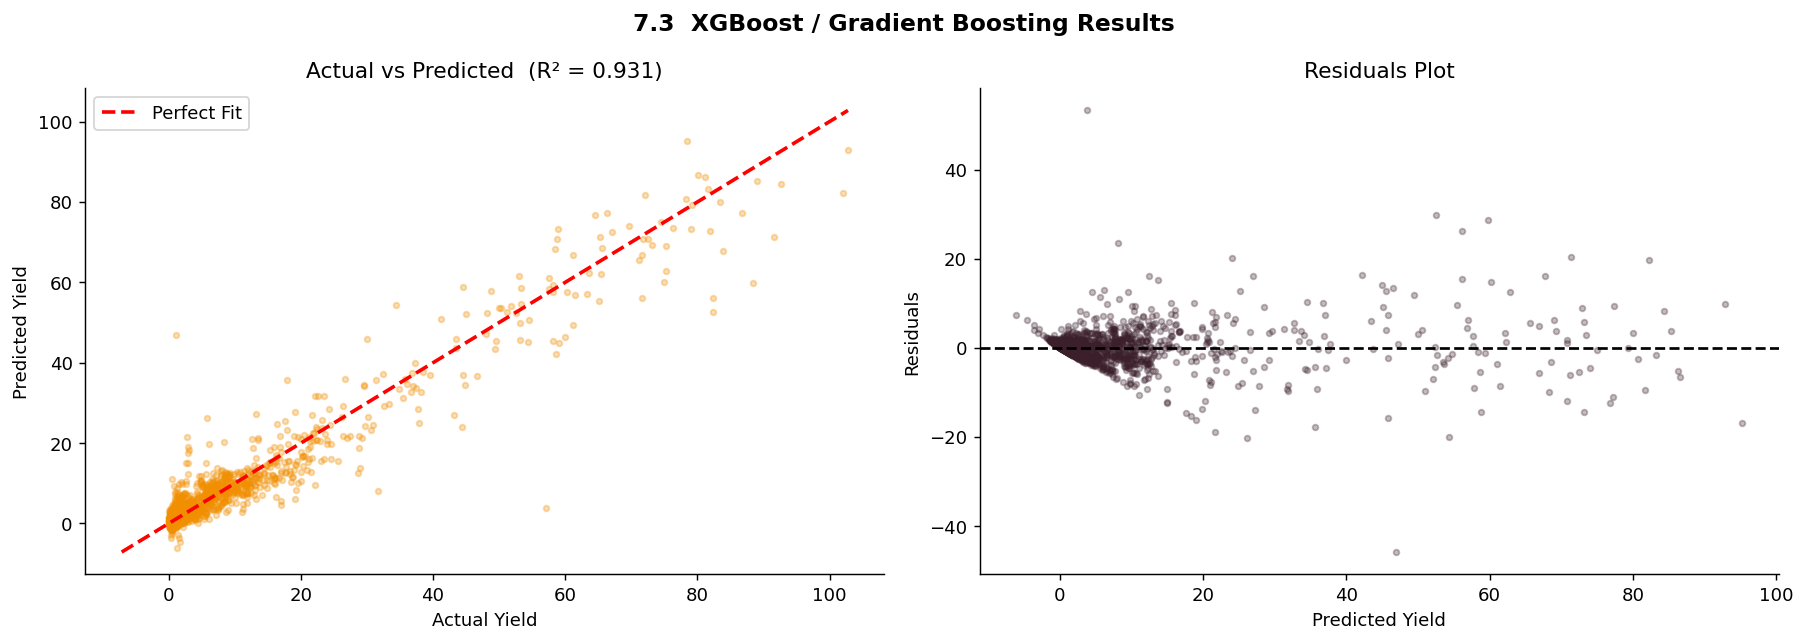

In [34]:
# Using sklearn GradientBoostingRegressor (XGBoost-equivalent)
xgb = GradientBoostingRegressor(
    n_estimators=200, learning_rate=0.1, max_depth=5,
    subsample=0.8, random_state=42
)
xgb.fit(X_train, y_train)  # Tree-based: no scaling needed
y_pred_xgb = xgb.predict(X_test)

r2_xgb   = r2_score(y_test, y_pred_xgb)
mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb  = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)

print(" GRADIENT BOOSTING (XGBoost-equivalent)")
print(f"   R²   = {r2_xgb:.4f}")
print(f"   MAE  = {mae_xgb:.4f}")
print(f"   MSE  = {mse_xgb:.4f}")
print(f"   RMSE = {rmse_xgb:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('7.3  XGBoost / Gradient Boosting Results', fontsize=13, fontweight='bold')

axes[0].scatter(y_test, y_pred_xgb, alpha=0.3, s=10, color=PALETTE[2])
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Perfect Fit')
axes[0].set_xlabel('Actual Yield'); axes[0].set_ylabel('Predicted Yield')
axes[0].set_title(f'Actual vs Predicted  (R² = {r2_xgb:.3f})')
axes[0].legend()

residuals_xgb = y_test - y_pred_xgb
axes[1].scatter(y_pred_xgb, residuals_xgb, alpha=0.3, s=10, color=PALETTE[4])
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted Yield'); axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals Plot')

plt.tight_layout()
plt.show()

---
## 8. Feature Importance (XGBoost)

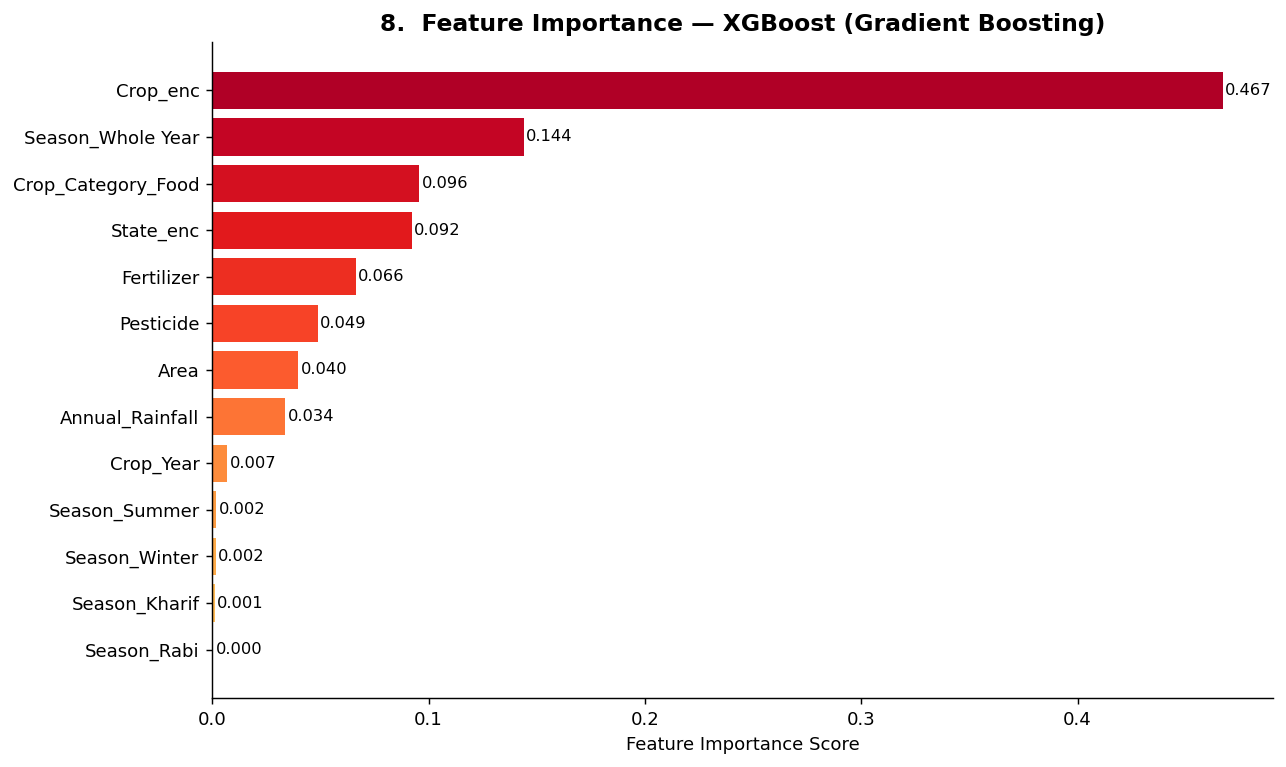

In [35]:
importances = xgb.feature_importances_
feat_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(feat_df)))
ax.barh(feat_df['Feature'], feat_df['Importance'], color=colors)
ax.set_title('8.  Feature Importance — XGBoost (Gradient Boosting)', fontsize=13, fontweight='bold')
ax.set_xlabel('Feature Importance Score')
for i, (v, n) in enumerate(zip(feat_df['Importance'], feat_df['Feature'])):
    ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 9. Model Comparison Dashboard

In [36]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'SVR (RBF)', 'XGBoost / GBR'],
    'R²':   [r2_lr,   r2_svr,   r2_xgb],
    'MAE':  [mae_lr,  mae_svr,  mae_xgb],
    'MSE':  [mse_lr,  mse_svr,  mse_xgb],
    'RMSE': [rmse_lr, rmse_svr, rmse_xgb],
})
print(results.to_string(index=False))
results

            Model       R²      MAE       MSE     RMSE
Linear Regression 0.197588 4.649170 87.567812 9.357767
        SVR (RBF) 0.325180 2.858234 73.643580 8.581584
    XGBoost / GBR 0.931488 1.170528  7.476792 2.734372


,Model,R²,MAE,MSE,RMSE
0,Linear Regression,0.197588,4.649170,87.567812,9.357767
1,SVR (RBF),0.325180,2.858234,73.643580,8.581584
2,XGBoost / GBR,0.931488,1.170528,7.476792,2.734372


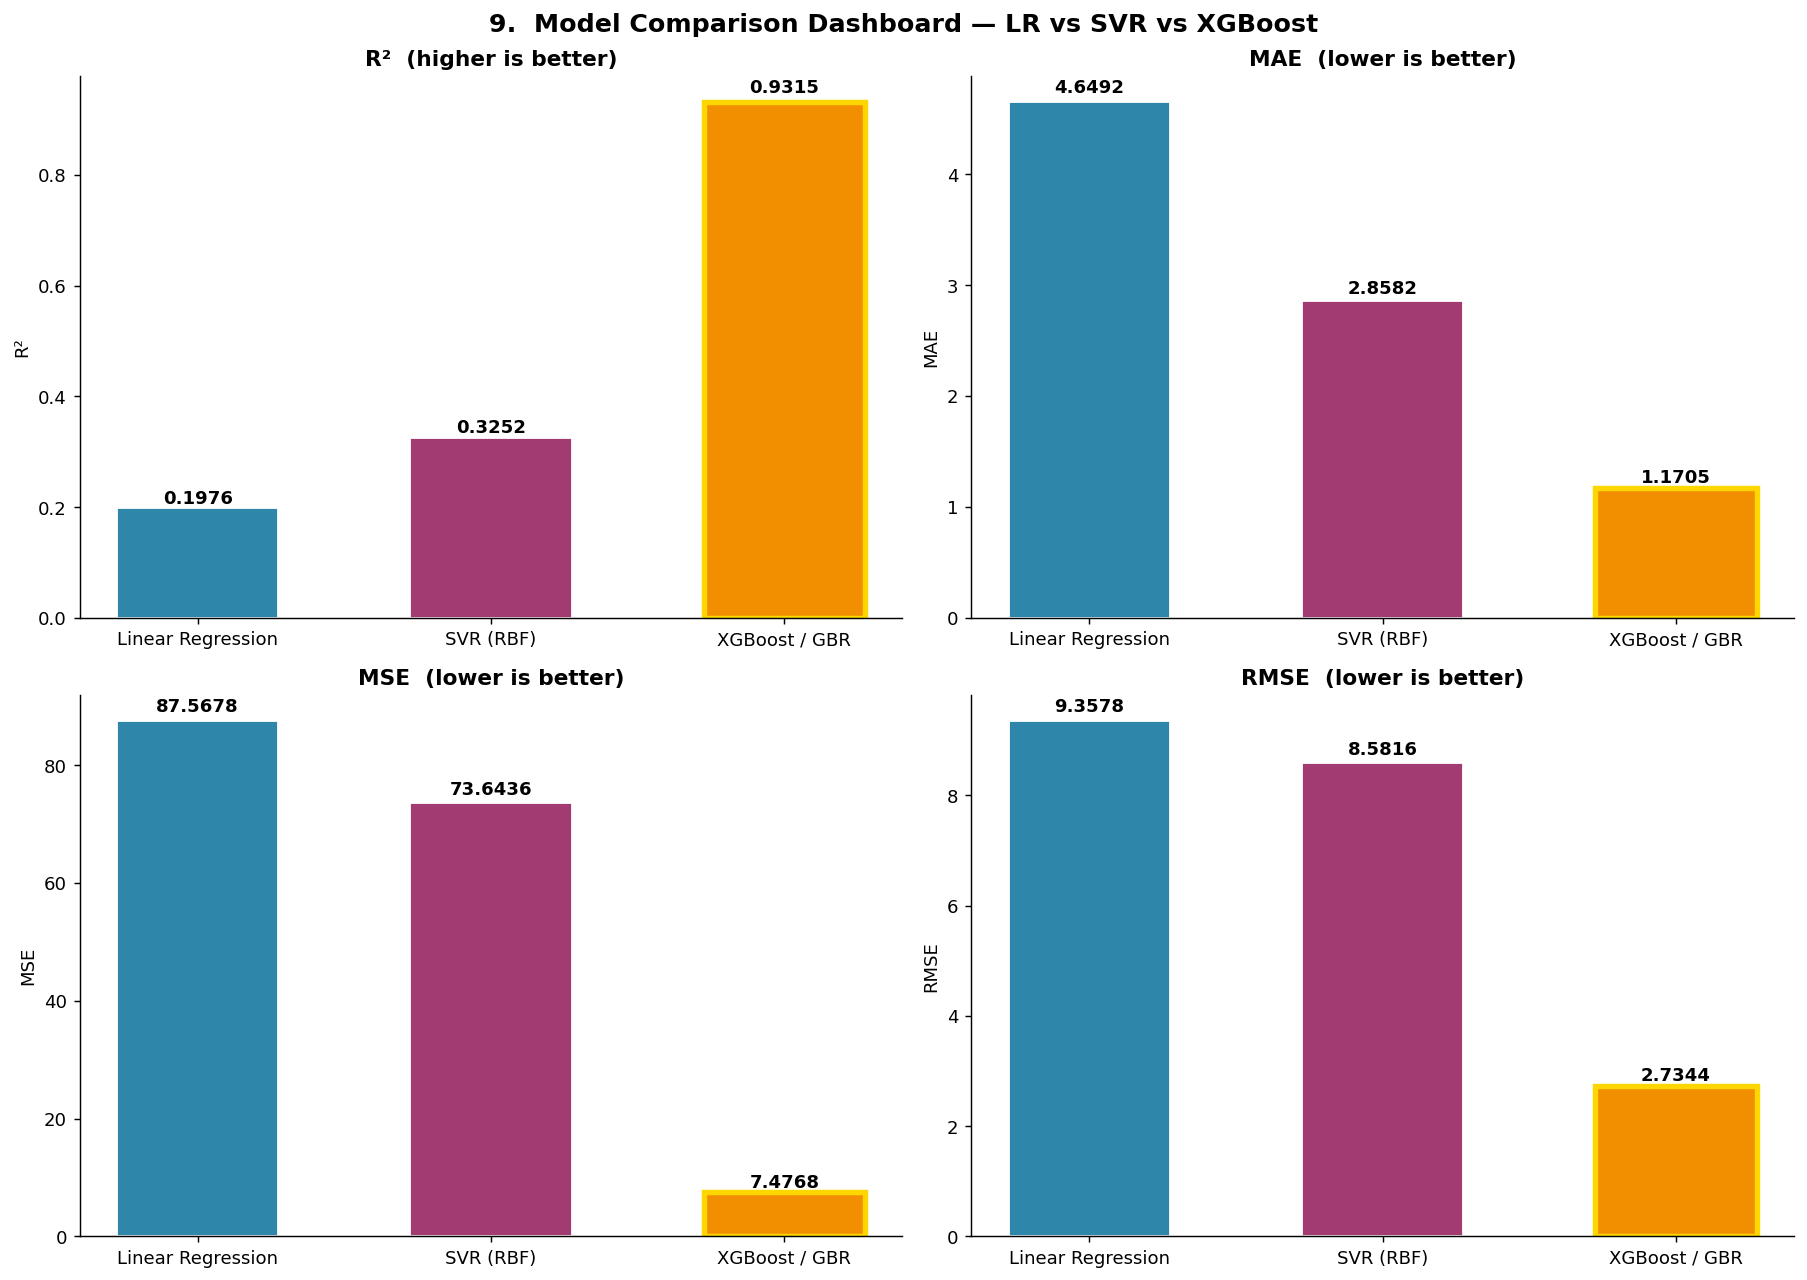

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('9.  Model Comparison Dashboard — LR vs SVR vs XGBoost', fontsize=14, fontweight='bold')

models = results['Model']
bar_colors = [PALETTE[0], PALETTE[1], PALETTE[2]]
x = np.arange(len(models))

for ax, metric, better in [
    (axes[0,0], 'R²',   'higher'),
    (axes[0,1], 'MAE',  'lower'),
    (axes[1,0], 'MSE',  'lower'),
    (axes[1,1], 'RMSE', 'lower'),
]:
    vals = results[metric]
    bars = ax.bar(x, vals, color=bar_colors, edgecolor='white', width=0.55)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=10)
    ax.set_title(f'{metric}  ({better} is better)', fontweight='bold')
    ax.set_ylabel(metric)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    # Highlight best
    best_idx = vals.idxmax() if better == 'higher' else vals.idxmin()
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(3)

plt.tight_layout()
plt.show()

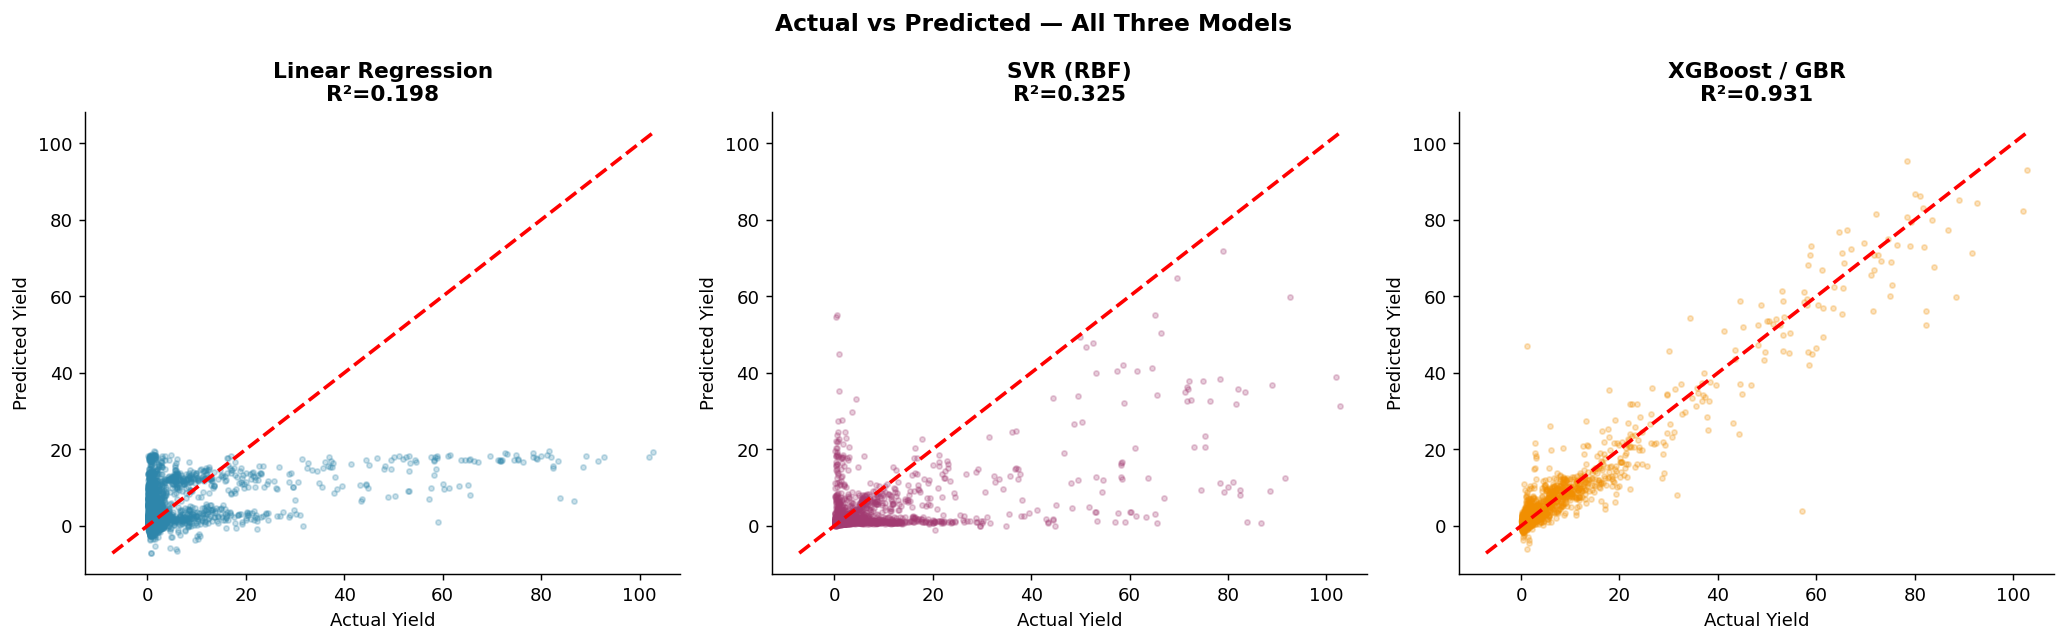

In [38]:
# Side-by-side Actual vs Predicted for all 3 models
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Actual vs Predicted — All Three Models', fontsize=13, fontweight='bold')

for ax, preds, title, color in [
    (axes[0], y_pred_lr,  f'Linear Regression\nR²={r2_lr:.3f}',  PALETTE[0]),
    (axes[1], y_pred_svr, f'SVR (RBF)\nR²={r2_svr:.3f}',        PALETTE[1]),
    (axes[2], y_pred_xgb, f'XGBoost / GBR\nR²={r2_xgb:.3f}',   PALETTE[2]),
]:
    ax.scatter(y_test, preds, alpha=0.25, s=8, color=color)
    ax.plot(lims, lims, 'r--', linewidth=2)
    ax.set_xlabel('Actual Yield')
    ax.set_ylabel('Predicted Yield')
    ax.set_title(title, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 10. Additional Insights

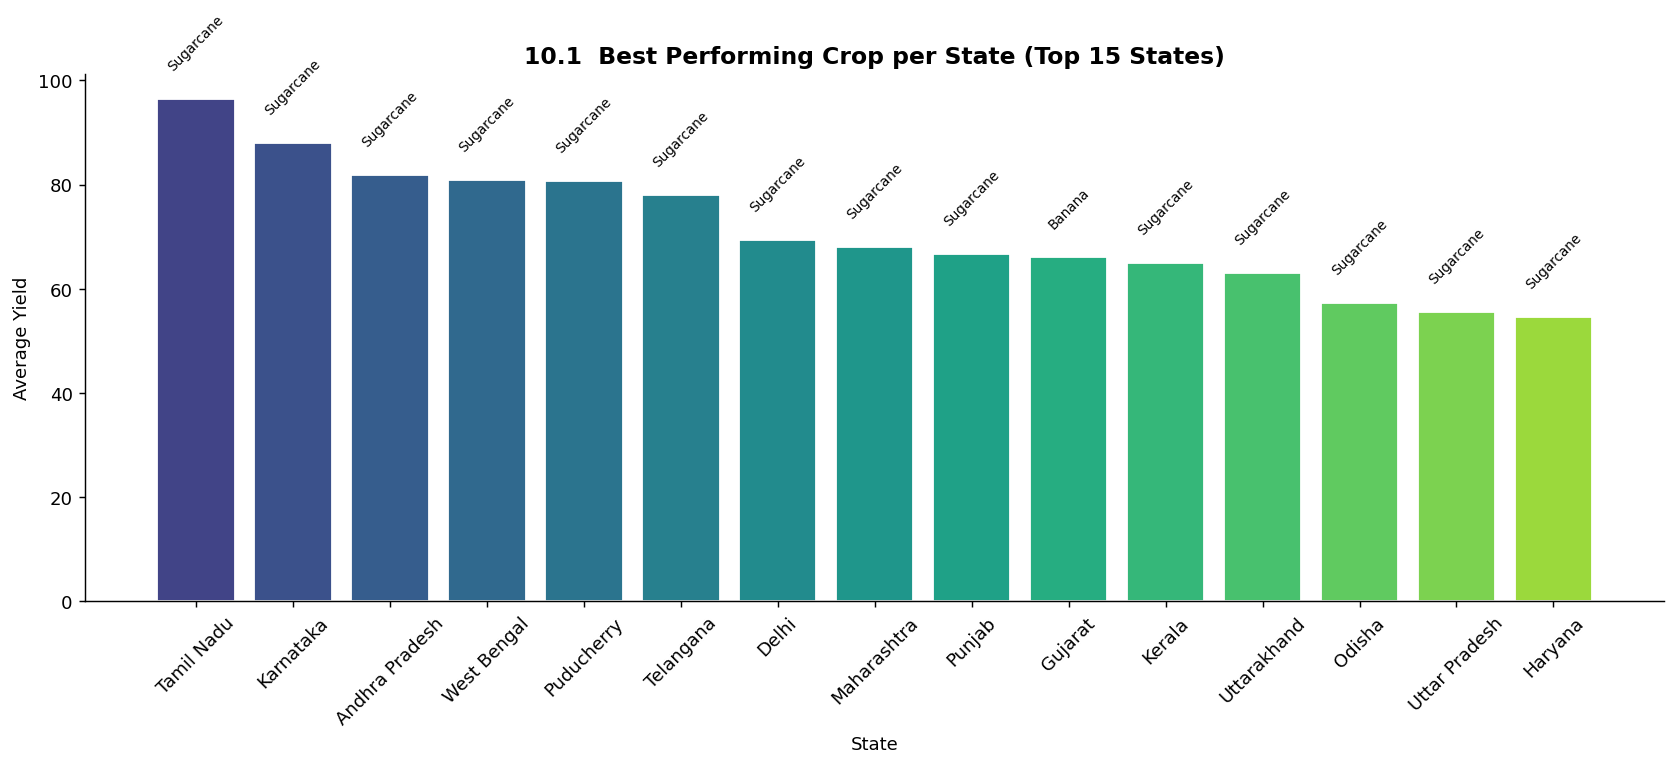

In [39]:
# --- 10.1 Top Crops per State ---
top_crop_state = (
    df_clean.groupby(['State', 'Crop'])['Yield']
    .mean()
    .reset_index()
    .sort_values('Yield', ascending=False)
    .groupby('State')
    .first()
    .reset_index()
    .rename(columns={'Crop': 'Best Crop', 'Yield': 'Avg Yield'})
    .sort_values('Avg Yield', ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(top_crop_state['State'], top_crop_state['Avg Yield'],
              color=plt.cm.viridis(np.linspace(0.2, 0.85, len(top_crop_state))),
              edgecolor='white')
for bar, crop in zip(bars, top_crop_state['Best Crop']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            crop, ha='center', va='bottom', fontsize=7.5, rotation=45)
ax.set_title('10.1  Best Performing Crop per State (Top 15 States)', fontsize=13, fontweight='bold')
ax.set_xlabel('State')
ax.set_ylabel('Average Yield')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 10.1b  Top Crops Specific to Each State



🌾 Top 3 Crops per State (by average yield):
Rank                          Top 1             Top 2                Top 3
State                                                                     
Andhra Pradesh     Sugarcane (81.7)     Banana (29.8)         Onion (20.3)
Arunachal Pradesh  Sugarcane (19.0)      Potato (7.1)         Ginger (6.2)
Assam              Sugarcane (37.5)     Banana (15.0)          Jute (10.0)
Bihar              Sugarcane (48.3)     Banana (18.2)  Sweet potato (13.1)
Chhattisgarh           Bajra (17.1)       Onion (7.0)      Sugarcane (6.0)
Delhi              Sugarcane (69.3)     Potato (13.9)          Maize (8.0)
Goa                Sugarcane (51.3)      Banana (9.6)           Rice (2.7)
Gujarat               Banana (66.1)  Sugarcane (65.7)         Onion (27.0)
Haryana            Sugarcane (54.6)     Potato (22.0)         Onion (20.0)
Himachal Pradesh   Sugarcane (12.5)      Potato (8.3)          Onion (7.6)
Jammu and Kashmir     Potato (10.3)   Sugarcane (2.1)  

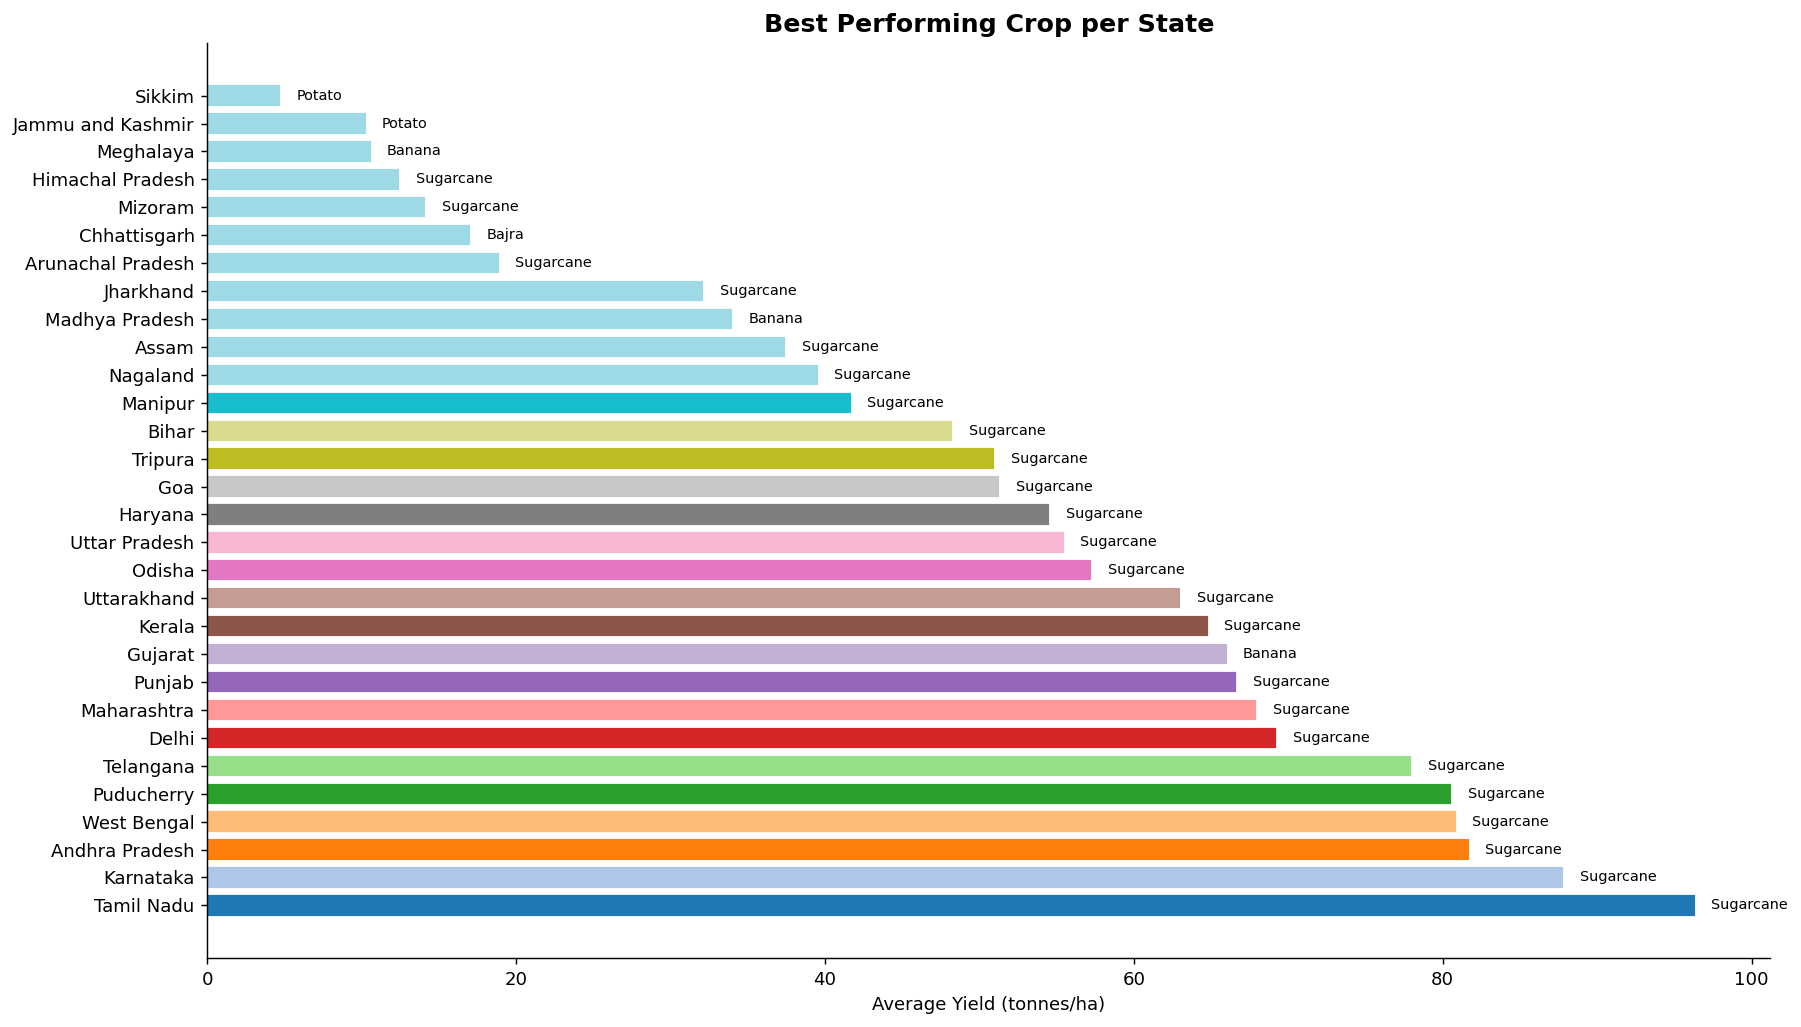

In [40]:
# --- State-wise Top Crops (detailed heatmap) ---
state_top3 = (
    df_clean.groupby(['State', 'Crop'])['Yield']
    .mean().reset_index()
    .sort_values('Yield', ascending=False)
    .groupby('State').head(3)
    .reset_index(drop=True)
)

# Pivot: state × rank
state_top3['Rank'] = state_top3.groupby('State').cumcount() + 1
pivot_crops = state_top3.pivot(index='State', columns='Rank', values='Crop').add_prefix('Top ')
pivot_yield = state_top3.pivot(index='State', columns='Rank', values='Yield').add_prefix('Top ')

print('\n🌾 Top 3 Crops per State (by average yield):')
combined = pivot_crops.copy()
for col in pivot_crops.columns:
    rank_n = col.split()[-1]
    combined[col] = pivot_crops[col] + ' (' + pivot_yield['Top ' + rank_n].round(1).astype(str) + ')'
print(combined.to_string())

# Visualise: top crop per state
top1 = state_top3[state_top3['Rank'] == 1].sort_values('Yield', ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(top1['State'], top1['Yield'],
               color=plt.cm.tab20(range(len(top1))), edgecolor='white')
for bar, crop in zip(bars, top1['Crop']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            crop, va='center', fontsize=8)
ax.set_title('Best Performing Crop per State', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Yield (tonnes/ha)')
plt.tight_layout()
plt.show()


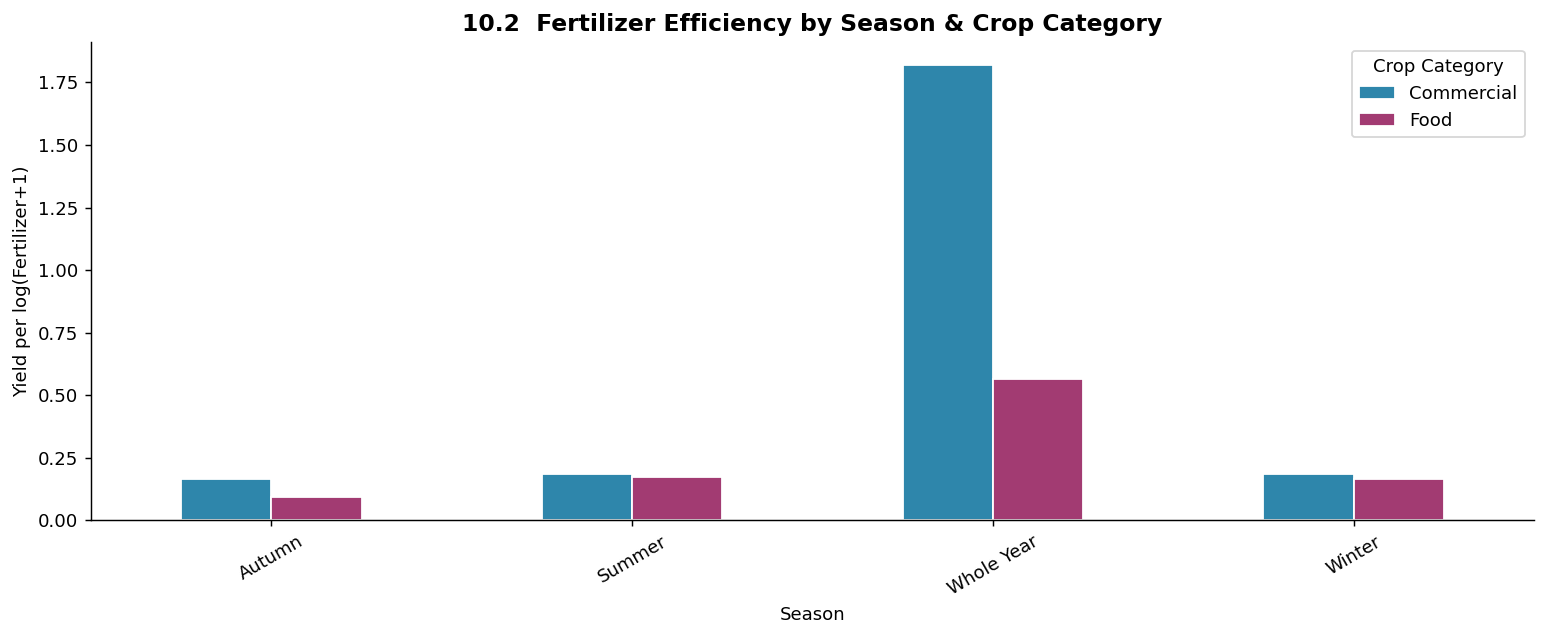

In [41]:
# --- 10.2 Fertilizer Efficiency: Yield per Unit Fertilizer by Crop Category ---
df_clean['Fert_Efficiency'] = df_clean['Yield'] / (np.log1p(df_clean['Fertilizer']))

eff_season = df_clean.groupby(['Season','Crop_Category'])['Fert_Efficiency'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
pivot = eff_season.pivot(index='Season', columns='Crop_Category', values='Fert_Efficiency')
pivot.plot(kind='bar', ax=ax, color=[PALETTE[0], PALETTE[1]], edgecolor='white')
ax.set_title('10.2  Fertilizer Efficiency by Season & Crop Category', fontsize=13, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Yield per log(Fertilizer+1)')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Crop Category')
plt.tight_layout()
plt.show()

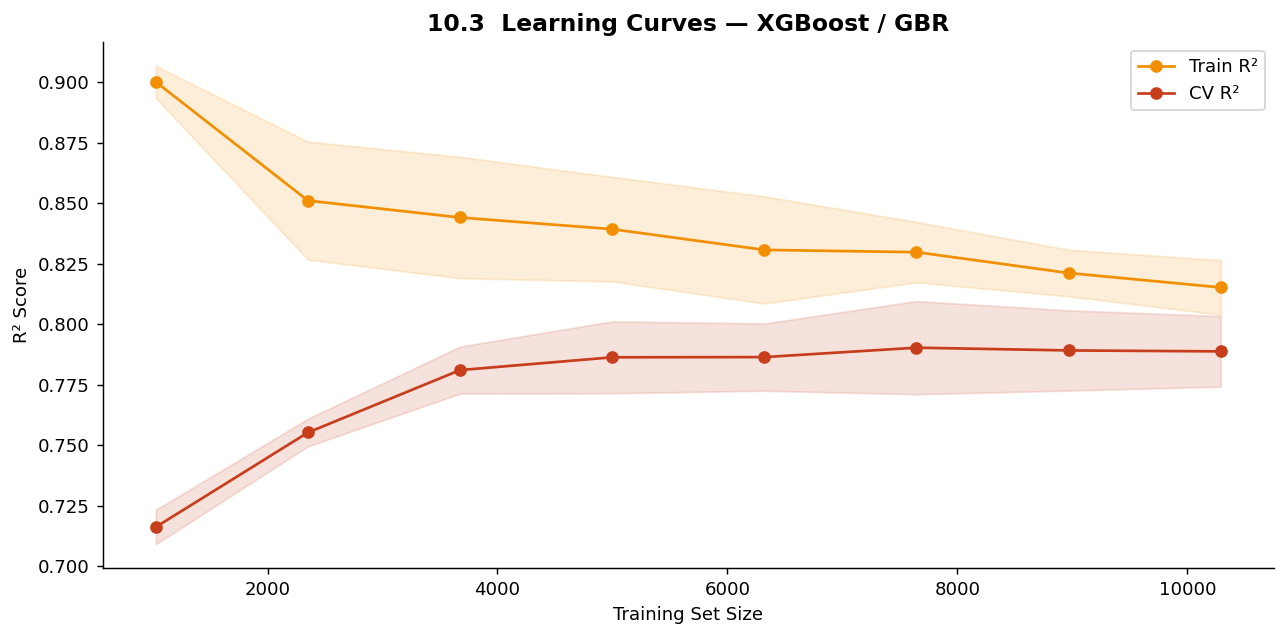

In [42]:
# --- 10.3 Learning Curves (XGBoost) ---
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    GradientBoostingRegressor(n_estimators=100, random_state=42),
    X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    scoring='r2', cv=3, n_jobs=-1
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', color=PALETTE[2], label='Train R²')
ax.fill_between(train_sizes,
                train_scores.mean(1) - train_scores.std(1),
                train_scores.mean(1) + train_scores.std(1), alpha=0.15, color=PALETTE[2])
ax.plot(train_sizes, test_scores.mean(axis=1), 'o-', color=PALETTE[3], label='CV R²')
ax.fill_between(train_sizes,
                test_scores.mean(1) - test_scores.std(1),
                test_scores.mean(1) + test_scores.std(1), alpha=0.15, color=PALETTE[3])
ax.set_title('10.3  Learning Curves — XGBoost / GBR', fontsize=13, fontweight='bold')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('R² Score')
ax.legend()
plt.tight_layout()
plt.show()

---
## 11. Summary & Conclusions

In [43]:
print("=" * 65)
print(" CROP YIELD PREDICTION — FINAL RESULTS SUMMARY")
print("=" * 65)

print("\nMODEL PERFORMANCE:")
print(results.to_string(index=False))

best_r2  = results.loc[results['R²'].idxmax(),  'Model']
best_mae = results.loc[results['MAE'].idxmin(), 'Model']
print(f"\n    Best R²  : {best_r2}  ({results['R²'].max():.4f})")
print(f"    Best MAE : {best_mae} ({results['MAE'].min():.4f})")

print("\n\n HYPOTHESIS OUTCOMES:")
print(f"   H1 — Rainfall Impact : Pearson r={corr_r:.3f}, p={p_val_r:.4f} → {'REJECTED H₀ ' if p_val_r<0.05 else 'Not Rejected '}")
print(f"   H2 — Fertilizer      : r={corr_f:.3f}, p={p_val_f:.4f}   → {'REJECTED H₀ ' if p_val_f<0.05 else 'Not Rejected '}")
print(f"   H2 — Pesticide       : r={corr_p:.3f}, p={p_val_p:.4f}   → {'REJECTED H₀ ' if p_val_p<0.05 else 'Not Rejected '}")
print(f"   H3 — Crop Volatility : Levene p={p_val_h3:.4f}            → {'REJECTED H₀ ' if p_val_h3<0.05 else 'Not Rejected '}")

print("\n\n KEY INSIGHTS:")
print(f"   • Top feature driving yield: {feat_df.iloc[-1]['Feature']}")
print(f"   • Food crop yield std dev  : {food_yield.std():.2f}")
print(f"   • Commercial crop yield std: {commercial_yield.std():.2f}")
print(f"   • Commercial crops are ~{commercial_yield.std()/food_yield.std():.1f}× more volatile")

print("\n" + "=" * 65)

 CROP YIELD PREDICTION — FINAL RESULTS SUMMARY

MODEL PERFORMANCE:
            Model       R²      MAE       MSE     RMSE
Linear Regression 0.197588 4.649170 87.567812 9.357767
        SVR (RBF) 0.325180 2.858234 73.643580 8.581584
    XGBoost / GBR 0.931488 1.170528  7.476792 2.734372

    Best R²  : XGBoost / GBR  (0.9315)
    Best MAE : XGBoost / GBR (1.1705)


 HYPOTHESIS OUTCOMES:
   H1 — Rainfall Impact : Pearson r=-0.025, p=0.0006 → REJECTED H₀ 
   H2 — Fertilizer      : r=-0.002, p=0.7673   → Not Rejected 
   H2 — Pesticide       : r=-0.002, p=0.7420   → Not Rejected 
   H3 — Crop Volatility : Levene p=0.0000            → REJECTED H₀ 


 KEY INSIGHTS:
   • Top feature driving yield: Crop_enc
   • Food crop yield std dev  : 6.08
   • Commercial crop yield std: 18.88
   • Commercial crops are ~3.1× more volatile

